# SDG Indicator Text Classification

Multi-label classification of Devex text documents into **SDG Goal 3** indicators (27 labels).

**Primary metric:** Hamming loss (lower is better)

---

## Notebook workflow

| Step | Content |
|------|---------|
| STEP 1 | Install dependencies + imports |
| STEP 2 | Load `Devex_train.csv` / `Devex_test_questions.csv` |
| STEP 3 | Parse labels + EDA (imbalance, co-occurrence) |
| STEP 4 | Text preprocessing pipeline + ablation experiments |
| STEP 5 | Experiment 1 (baseline) |
| STEP 6 | Classification report, confusion matrices, learning curves |
| STEP 7 | Baseline test predictions (optional) |
| STEP 8 | **Experiments 1–10** (with rationale between groups) |
| STEP 8b | Learning curves & confusion matrices — **all experiments** |
| STEP 9 | Best-model test predictions |
| STEP 10 | Report exports (CSV + figures) |

**Google Colab:** Upload both CSV files to the same folder as this notebook, then *Runtime → Run all*.

**GitHub:** All code lives in this single notebook (`SGD_indicator.ipynb`).



In [1]:
# STEP 1: Install + import libraries
%pip install -q pandas numpy matplotlib seaborn scikit-learn beautifulsoup4 nltk

import warnings
warnings.filterwarnings("ignore")

import os
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from bs4 import BeautifulSoup
import nltk
from nltk.corpus import stopwords as nltk_stopwords
from nltk.stem import WordNetLemmatizer
nltk.download("stopwords", quiet=True)
nltk.download("wordnet", quiet=True)
nltk.download("omw-1.4", quiet=True)

from sklearn.model_selection import train_test_split, learning_curve
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.multiclass import OneVsRestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    hamming_loss, f1_score, precision_score, recall_score,
    classification_report, multilabel_confusion_matrix,
)

%matplotlib inline

try:
    from google.colab import files  # noqa: F401
    IN_COLAB = True
    print("Running in Google Colab — place Devex_train.csv and Devex_test_questions.csv in /content/")
except ImportError:
    IN_COLAB = False

print(f"pandas {pd.__version__} | numpy {np.__version__} | colab={IN_COLAB}")



[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
pandas 3.0.3 | numpy 2.4.6 | colab=False


In [2]:
# STEP 2: Load datasets
from IPython.display import display

TRAIN_PATH = "Devex_train.csv"
TEST_PATH = "Devex_test_questions.csv"

train_df = pd.read_csv(TRAIN_PATH, encoding="latin-1")
test_df = pd.read_csv(TEST_PATH, encoding="latin-1")

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

# snip display of the train and test datasets
print("\nTrain data (first 2 rows):")
display(train_df.head(2))

print("\nTest data (first 2 rows):")
display(test_df.head(2))


Train shape: (2995, 15)
Test shape: (998, 3)

Train data (first 2 rows):


,Unique ID,Type,Text,Label 1,Label 2,Label 3,Label 4,Label 5,Label 6,Label 7,Label 8,Label 9,Label 10,Label 11,Label 12
0,12555,Grant,Centers of Biomedical Research Excellence (COB...,3.b.2 - Total net official development assista...,3.c.1 - Health worker density and distribution,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,14108,Grant,Research on Regenerative Medicine <h2><strong>...,3.b.2 - Total net official development assista...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



Test data (first 2 rows):


,Unique ID,Type,Text
0,49848,Organization,4th Sector Health: <p>4th Sector Health is a U...
1,52348,Organization,Action for Global Health: <p>Action for Global...


## STEP 3: Parse labels + exploratory data analysis (EDA)

Train labels are stored in `Label 1`–`Label 12` as indicator strings; unused slots are `NaN`/`NA`. We convert them to a binary matrix for multi-label modeling and explore the dataset before preprocessing.

In [3]:
LABEL_COLS = [f"Label {i}" for i in range(1, 13)]


def extract_labels(row):
    """Return active SDG indicator strings for one row (ignore NA/NaN/empty)."""
    labels = []
    for col in LABEL_COLS:
        value = row[col]
        if pd.isna(value):
            continue
        value = str(value).strip()
        if value and value.upper() != "NA":
            labels.append(value)
    return labels


train_df["labels"] = train_df.apply(extract_labels, axis=1)
train_df["n_labels"] = train_df["labels"].apply(len)

# Build fixed label vocabulary from training set only
mlb = MultiLabelBinarizer()
Y = mlb.fit_transform(train_df["labels"])
label_names = mlb.classes_

print(f"Number of unique SDG 3 indicators: {len(label_names)}")
print(f"Label matrix shape (samples × labels): {Y.shape}")
print(f"Labels per document — min: {train_df['n_labels'].min()}, "
      f"max: {train_df['n_labels'].max()}, "
      f"mean: {train_df['n_labels'].mean():.2f}")

# Shared split settings for preprocessing ablation, baseline, and experiments 1–10
RANDOM_STATE = 42
TEST_SIZE = 0.2
y = Y

display(train_df[["Unique ID", "Type", "n_labels", "labels"]].head(3))

Number of unique SDG 3 indicators: 27
Label matrix shape (samples × labels): (2995, 27)
Labels per document — min: 1, max: 10, mean: 1.98


,Unique ID,Type,n_labels,labels
0,12555,Grant,2,[3.b.2 - Total net official development assist...
1,14108,Grant,1,[3.b.2 - Total net official development assist...
2,23168,Organization,4,[3.d.1 - International Health Regulations (IHR...


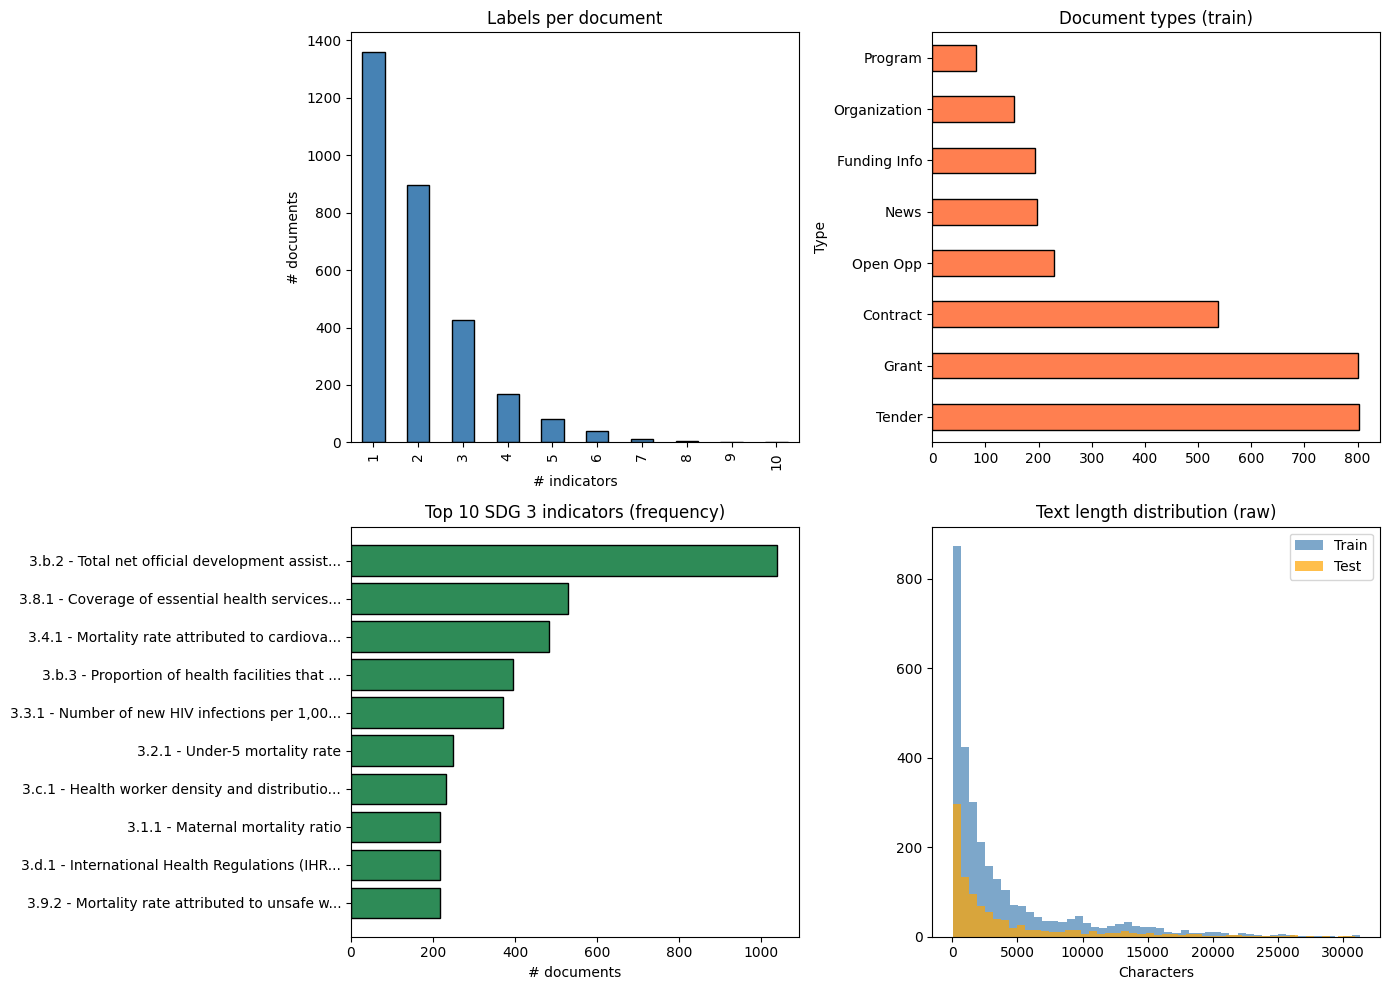


Label prevalence (documents containing each indicator):


,count
3.b.2 - Total net official development assistance to medical research and basic health sector,1040
"3.8.1 - Coverage of essential health services (defined as the average coverage of essential services based on tracer interventions that include reproductive, maternal, newborn and child health, infectious diseases, non-communicable diseases and service capacity and access, among the general and the most disadvantaged population)",529
"3.4.1 - Mortality rate attributed to cardiovascular disease, cancer, diabetes or chronic respiratory disease",483
3.b.3 - Proportion of health facilities that have a core set of relevant essential medicines available and affordable on a sustainable basis,394
"3.3.1 - Number of new HIV infections per 1,000 uninfected population, by sex, age and key populations",371
3.2.1 - Under-5 mortality rate,249
3.c.1 - Health worker density and distribution,232
3.1.1 - Maternal mortality ratio,218
"3.9.2 - Mortality rate attributed to unsafe water, unsafe sanitation and lack of hygiene (exposure to unsafe Water, Sanitation and Hygiene for All (WASH) services)",217
3.d.1 - International Health Regulations (IHR) capacity and health emergency preparedness,217


In [4]:
# EDA visualizations

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1) Labels per document
train_df["n_labels"].value_counts().sort_index().plot(
    kind="bar", ax=axes[0, 0], color="steelblue", edgecolor="black"
)
axes[0, 0].set_title("Labels per document")
axes[0, 0].set_xlabel("# indicators")
axes[0, 0].set_ylabel("# documents")

# 2) Document type distribution
train_df["Type"].value_counts().plot(
    kind="barh", ax=axes[0, 1], color="coral", edgecolor="black"
)
axes[0, 1].set_title("Document types (train)")

# 3) Top 10 most frequent indicators
label_counts = Y.sum(axis=0)
top_idx = np.argsort(label_counts)[::-1][:10]
top_labels = [label_names[i][:45] + "..." if len(label_names[i]) > 45 else label_names[i]
              for i in top_idx]
axes[1, 0].barh(top_labels[::-1], label_counts[top_idx][::-1], color="seagreen", edgecolor="black")
axes[1, 0].set_title("Top 10 SDG 3 indicators (frequency)")
axes[1, 0].set_xlabel("# documents")

# 4) Text length (characters) before cleaning
train_df["text_len"] = train_df["Text"].astype(str).str.len()
test_df["text_len"] = test_df["Text"].astype(str).str.len()
axes[1, 1].hist(train_df["text_len"], bins=50, alpha=0.7, label="Train", color="steelblue")
axes[1, 1].hist(test_df["text_len"], bins=50, alpha=0.7, label="Test", color="orange")
axes[1, 1].set_title("Text length distribution (raw)")
axes[1, 1].set_xlabel("Characters")
axes[1, 1].legend()

plt.tight_layout()
plt.show()

print("\nLabel prevalence (documents containing each indicator):")
prevalence = pd.Series(label_counts, index=label_names).sort_values(ascending=False)
display(prevalence.head(10).to_frame("count"))

### Class imbalance analysis

The dataset is **highly imbalanced** across the 27 SDG 3 indicators. The most frequent label (3.b.2) appears in ~35% of documents, while several indicators appear in fewer than 50 training examples. This motivates `class_weight='balanced'` in our classifiers (tested explicitly in Experiment 9) and macro-F1 as a secondary metric alongside Hamming loss.


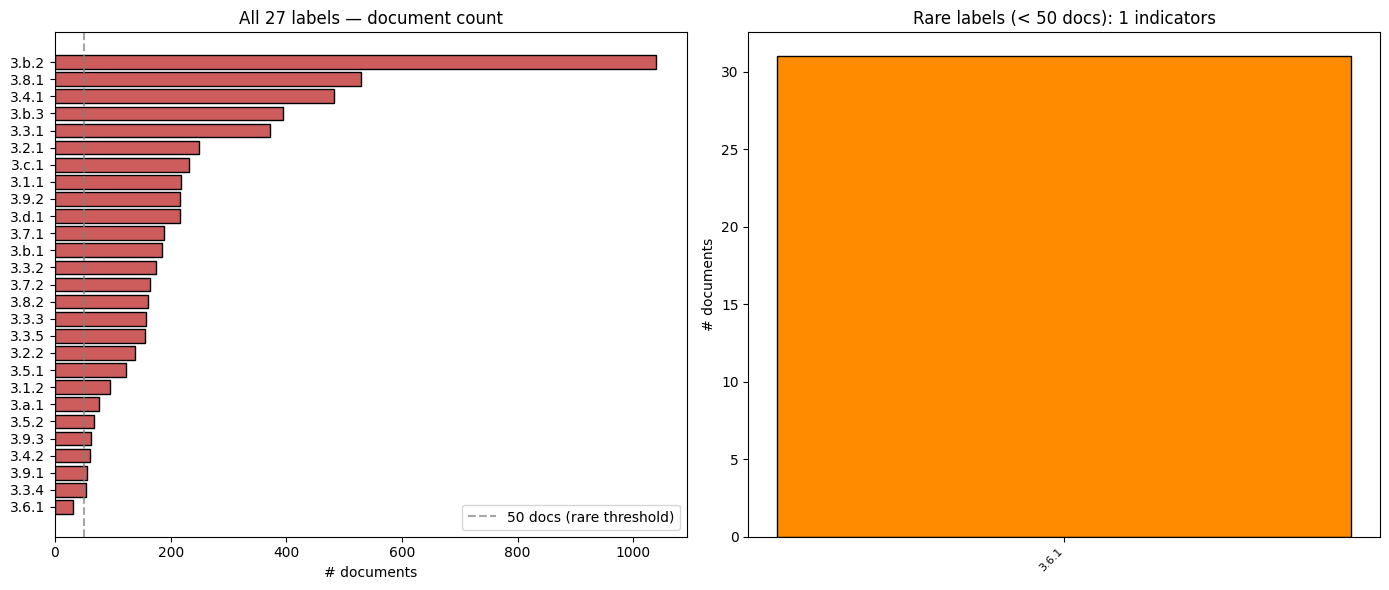

Most frequent: 3.b.2 - Total net official development assistance ... (1040 docs)
Least frequent: 3.6.1 - Death rate due to road traffic injuries... (31 docs)
Imbalance ratio (max/min): 33.5x


,indicator,count,pct_documents,imbalance_ratio
23,3.b.2 - Total net official development assista...,1040,34.72,1.0
16,3.8.1 - Coverage of essential health services ...,529,17.66,2.0
9,3.4.1 - Mortality rate attributed to cardiovas...,483,16.13,2.2
24,3.b.3 - Proportion of health facilities that h...,394,13.16,2.6
4,"3.3.1 - Number of new HIV infections per 1,000...",371,12.39,2.8


,indicator,count,pct_documents,imbalance_ratio
20,3.9.3 - Mortality rate attributed to unintenti...,63,2.10,16.5
10,3.4.2 - Suicide mortality rate,61,2.04,17.0
18,3.9.1 - Mortality rate attributed to household...,55,1.84,18.9
7,"3.3.4 - Hepatitis B incidence per 100,000 popu...",53,1.77,19.6
13,3.6.1 - Death rate due to road traffic injuries,31,1.04,33.5


In [5]:
# Class imbalance: full label distribution + imbalance ratio
label_counts = Y.sum(axis=0)
prevalence = pd.Series(label_counts, index=label_names).sort_values(ascending=False)
max_count = prevalence.max()
min_count = prevalence.min()

imbalance_df = pd.DataFrame({
    "indicator": label_names,
    "count": label_counts,
    "pct_documents": (label_counts / len(train_df) * 100).round(2),
    "imbalance_ratio": (max_count / np.maximum(label_counts, 1)).round(1),
}).sort_values("count", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
short_all = imbalance_df["indicator"].str.replace(r"^(\d+\.\S+) - .*", r"\1", regex=True)
axes[0].barh(short_all.iloc[::-1], imbalance_df["count"].iloc[::-1], color="indianred", edgecolor="black")
axes[0].set_title("All 27 labels — document count")
axes[0].set_xlabel("# documents")
axes[0].axvline(50, color="gray", linestyle="--", alpha=0.7, label="50 docs (rare threshold)")
axes[0].legend()

rare = imbalance_df[imbalance_df["count"] < 50]
axes[1].bar(range(len(rare)), rare["count"], color="darkorange", edgecolor="black")
axes[1].set_xticks(range(len(rare)))
axes[1].set_xticklabels(
    rare["indicator"].str.replace(r"^(\d+\.\S+) - .*", r"\1", regex=True),
    rotation=45, ha="right", fontsize=8,
)
axes[1].set_title(f"Rare labels (< 50 docs): {len(rare)} indicators")
axes[1].set_ylabel("# documents")
plt.tight_layout()
plt.show()

print(f"Most frequent: {prevalence.index[0][:50]}... ({int(max_count)} docs)")
print(f"Least frequent: {prevalence.index[-1][:50]}... ({int(min_count)} docs)")
print(f"Imbalance ratio (max/min): {max_count/min_count:.1f}x")
display(imbalance_df.head(5))
display(imbalance_df.tail(5))


### Label co-occurrence analysis

In multi-label problems, labels are not independent — documents often map to several related SDG 3 indicators. We compute the **co-occurrence matrix** (how often each pair of labels appears in the same document) to understand label correlations that One-vs-Rest classifiers must handle.


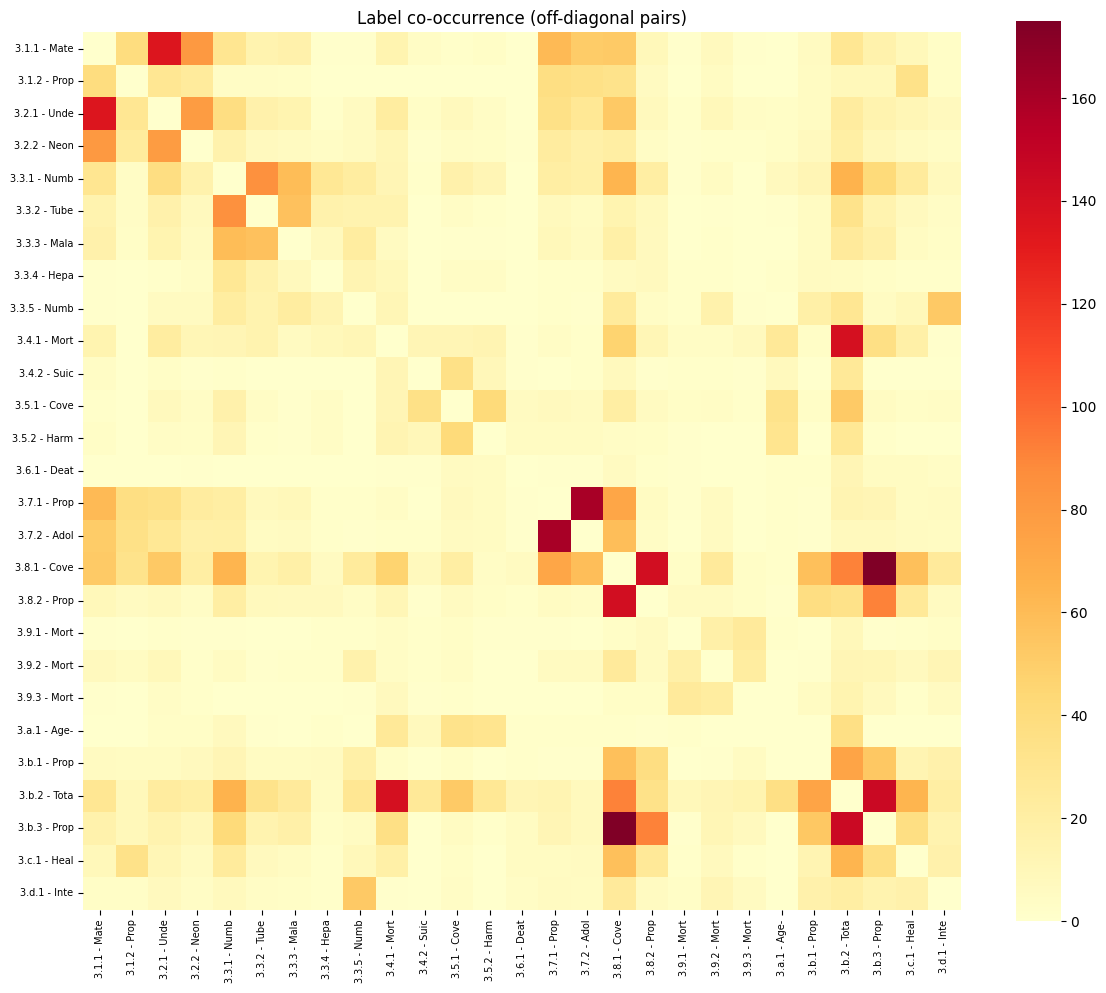

Top 10 co-occurring label pairs:


,label_a,label_b,co_count
256,3.8.1 - Coverage of essential health services ...,3.b.3 - Proportion of health facilities that h...,175
229,3.7.1 - Proportion of women of reproductive ag...,3.7.2 - Adolescent birth rate (aged 10_14 year...,160
291,3.b.2 - Total net official development assista...,3.b.3 - Proportion of health facilities that h...,145
249,3.8.1 - Coverage of essential health services ...,3.8.2 - Proportion of population with large ho...,141
179,3.4.1 - Mortality rate attributed to cardiovas...,3.b.2 - Total net official development assista...,140
1,3.1.1 - Maternal mortality ratio,3.2.1 - Under-5 mortality rate,135
255,3.8.1 - Coverage of essential health services ...,3.b.2 - Total net official development assista...,91
265,3.8.2 - Proportion of population with large ho...,3.b.3 - Proportion of health facilities that h...,91
85,"3.3.1 - Number of new HIV infections per 1,000...","3.3.2 - Tuberculosis incidence per 100,000 pop...",85
2,3.1.1 - Maternal mortality ratio,3.2.2 - Neonatal mortality rate,80


In [6]:
# Label co-occurrence matrix (27 x 27)
cooccur = Y.T @ Y
np.fill_diagonal(cooccur, 0)

short_names = [n[:12] for n in label_names]
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(
    cooccur, xticklabels=short_names, yticklabels=short_names,
    cmap="YlOrRd", ax=ax, square=True,
)
ax.set_title("Label co-occurrence (off-diagonal pairs)")
plt.xticks(rotation=90, fontsize=7)
plt.yticks(rotation=0, fontsize=7)
plt.tight_layout()
plt.show()

pairs = []
for i in range(len(label_names)):
    for j in range(i + 1, len(label_names)):
        if cooccur[i, j] > 0:
            pairs.append((label_names[i], label_names[j], int(cooccur[i, j])))
pairs_df = pd.DataFrame(pairs, columns=["label_a", "label_b", "co_count"]).sort_values("co_count", ascending=False)
print("Top 10 co-occurring label pairs:")
display(pairs_df.head(10))


## STEP 4: Text preprocessing pipeline

We apply a **staged preprocessing pipeline** and compare each stage as an ablation experiment:

| Stage | What it does | Rationale |
|-------|--------------|-----------|
| HTML removal | Strip tags via BeautifulSoup | Raw HTML adds noise; Experiment 4 confirms cleaning helps |
| Lowercasing | `text.lower()` | Reduces vocabulary fragmentation (Grant vs grant) |
| Stopword removal | Remove English function words | Tested at token level *and* via TF-IDF `stop_words` |
| Lemmatization | WordNet lemmatizer | Collapses inflected forms to base lemmas |

The baseline model uses the **best preprocessing variant** from the ablation below.


In [7]:
STOP_WORDS = set(nltk_stopwords.words("english"))
LEMMATIZER = WordNetLemmatizer()


def clean_html(text):
    """Remove HTML tags and normalize whitespace."""
    if pd.isna(text):
        return ""
    text = str(text)
    text = BeautifulSoup(text, "html.parser").get_text(separator=" ")
    return re.sub(r"\s+", " ", text).strip()


def preprocess_text(text, lowercase=False, remove_stopwords=False, lemmatize=False):
    """Full preprocessing pipeline with optional stages."""
    text = clean_html(text)
    if lowercase:
        text = text.lower()
    if remove_stopwords or lemmatize:
        tokens = text.split()
        if remove_stopwords:
            tokens = [t for t in tokens if t.lower() not in STOP_WORDS]
        if lemmatize:
            tokens = [LEMMATIZER.lemmatize(t.lower()) for t in tokens]
        text = " ".join(tokens)
    return text


PREP_VARIANTS = {
    "html_only": lambda t: preprocess_text(t),
    "lower": lambda t: preprocess_text(t, lowercase=True),
    "lower_nostop": lambda t: preprocess_text(t, lowercase=True, remove_stopwords=True),
    "lower_lemma": lambda t: preprocess_text(t, lowercase=True, remove_stopwords=True, lemmatize=True),
}

for name, fn in PREP_VARIANTS.items():
    col = f"prep_{name}"
    train_df[col] = train_df["Text"].apply(fn)
    test_df[col] = test_df["Text"].apply(fn)

train_df["clean_text"] = train_df["prep_html_only"]
test_df["clean_text"] = test_df["prep_html_only"]

print("Preprocessing preview (first train row):\n")
for name in PREP_VARIANTS:
    col = f"prep_{name}"
    print(f"{col} ({len(train_df.loc[0, col])} chars): {train_df.loc[0, col][:180]}...\n")

train_df["clean_len"] = train_df["clean_text"].str.len()
print(f"Avg length — raw: {train_df['text_len'].mean():.0f} | HTML cleaned: {train_df['clean_len'].mean():.0f}")


Preprocessing preview (first train row):

prep_html_only (2922 chars): Centers of Biomedical Research Excellence (COBRE) Phase III - Transitional Centers Funding Opportunity Description The Institutional Development Award (IDeA) Program endeavors to s...

prep_lower (2922 chars): centers of biomedical research excellence (cobre) phase iii - transitional centers funding opportunity description the institutional development award (idea) program endeavors to s...

prep_lower_nostop (2373 chars): centers biomedical research excellence (cobre) phase iii - transitional centers funding opportunity description institutional development award (idea) program endeavors stimulate r...

prep_lower_lemma (2335 chars): center biomedical research excellence (cobre) phase iii - transitional center funding opportunity description institutional development award (idea) program endeavor stimulate rese...

Avg length — raw: 3821 | HTML cleaned: 3271


### Preprocessing ablation (P1–P4)

**What changed:** Each variant adds one preprocessing stage on top of the previous (HTML → lowercase → stopwords → lemmatization).

**Why:** EDA shows long HTML-heavy documents with vocabulary spread across inflected forms. We need evidence for each normalization step rather than assuming lemmatization always helps.

**How EDA informed this:** Class imbalance and co-occurrence patterns suggest the model must generalize from limited text signal; cleaner, normalized tokens may help rare labels — but aggressive stemming can also remove discriminative terms.


P-html_only: Hamming loss=0.0615 | F1 micro=0.6200
P-lower: Hamming loss=0.0615 | F1 micro=0.6200
P-lower_nostop: Hamming loss=0.0615 | F1 micro=0.6201
P-lower_lemma: Hamming loss=0.0624 | F1 micro=0.6194


,variant,hamming_loss,f1_micro
0,html_only,0.061460,0.620031
1,lower,0.061460,0.620031
2,lower_nostop,0.061522,0.620084
3,lower_lemma,0.062388,0.619389



Best preprocessing variant: html_only — using for all downstream experiments


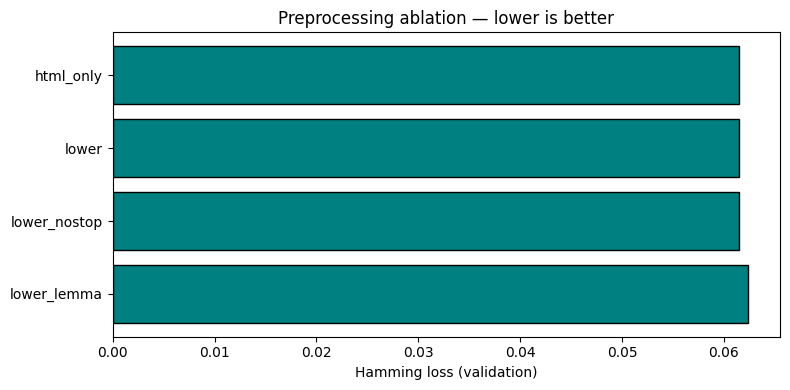

In [8]:
def quick_prep_eval(text_series, label=""):
    """Train/evaluate one preprocessing variant with baseline TF-IDF + LogReg."""
    idx = np.arange(len(text_series))
    idx_tr, idx_va = train_test_split(idx, test_size=TEST_SIZE, random_state=RANDOM_STATE)
    vec = TfidfVectorizer(max_features=15000, ngram_range=(1, 2), min_df=2, stop_words="english")
    X_tr = vec.fit_transform(text_series.iloc[idx_tr])
    X_va = vec.transform(text_series.iloc[idx_va])
    clf = OneVsRestClassifier(
        LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE)
    )
    clf.fit(X_tr, y[idx_tr])
    y_pred = clf.predict(X_va)
    return {
        "variant": label,
        "hamming_loss": hamming_loss(y[idx_va], y_pred),
        "f1_micro": f1_score(y[idx_va], y_pred, average="micro", zero_division=0),
    }


prep_ablation = []
for name in PREP_VARIANTS:
    metrics = quick_prep_eval(train_df[f"prep_{name}"], label=name)
    prep_ablation.append(metrics)
    print(f"P-{name}: Hamming loss={metrics['hamming_loss']:.4f} | F1 micro={metrics['f1_micro']:.4f}")

prep_ablation_df = pd.DataFrame(prep_ablation).sort_values("hamming_loss")
display(prep_ablation_df)

best_prep = prep_ablation_df.iloc[0]["variant"]
train_df["clean_text"] = train_df[f"prep_{best_prep}"]
test_df["clean_text"] = test_df[f"prep_{best_prep}"]
print(f"\nBest preprocessing variant: {best_prep} — using for all downstream experiments")

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(prep_ablation_df["variant"], prep_ablation_df["hamming_loss"], color="teal", edgecolor="black")
ax.set_xlabel("Hamming loss (validation)")
ax.set_title("Preprocessing ablation — lower is better")
ax.invert_yaxis()
plt.tight_layout()
plt.show()


## STEP 5: Experiment 1

**Setup:** TF-IDF + One-vs-Rest Logistic Regression on cleaned text.  
**Metric:** Hamming loss (lower is better).

In [10]:
RANDOM_STATE = 42
TEST_SIZE = 0.2

X = train_df["clean_text"]
y = Y  # binary matrix from STEP 3

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE
)

vectorizer = TfidfVectorizer(
    max_features=15000,
    ngram_range=(1, 2),
    min_df=2,
    stop_words="english",
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_val_tfidf = vectorizer.transform(X_val)

baseline_model = OneVsRestClassifier(
    LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE)
)
baseline_model.fit(X_train_tfidf, y_train)

y_val_pred = baseline_model.predict(X_val_tfidf)

val_hamming = hamming_loss(y_val, y_val_pred)
val_f1_micro = f1_score(y_val, y_val_pred, average="micro", zero_division=0)
val_f1_macro = f1_score(y_val, y_val_pred, average="macro", zero_division=0)

print("Experiment 1")
print(f"  Validation Hamming loss : {val_hamming:.4f}  (lower is better)")
print(f"  Validation F1 (micro)   : {val_f1_micro:.4f}")
print(f"  Validation F1 (macro)   : {val_f1_macro:.4f}")
print(f"  Train - val sizes       : {X_train_tfidf.shape[0]} - {X_val_tfidf.shape[0]}")
print(f"  TF-IDF features         : {X_train_tfidf.shape[1]}")

Experiment 1
  Validation Hamming loss : 0.0615  (lower is better)
  Validation F1 (micro)   : 0.6200
  Validation F1 (macro)   : 0.5496
  Train - val sizes       : 2396 - 599
  TF-IDF features         : 15000


## STEP 6: Results — classification report, confusion matrices, learning curves

For Experiment 1 (baseline) on the validation set we report:
- **Per-label precision / recall / F1** (full multi-label classification report)
- **Confusion matrices** for the most frequent labels
- **Learning curve** (Hamming loss vs. training set size) to check bias/variance


Multi-label classification report — Experiment 1 (validation):



,indicator,precision,recall,f1,support
4,"3.3.1 - Number of new HIV infections per 1,000...",0.890,0.833,0.861,78
6,"3.3.3 - Malaria incidence per 1,000 population",0.838,0.689,0.756,45
5,"3.3.2 - Tuberculosis incidence per 100,000 pop...",0.773,0.723,0.747,47
23,3.b.2 - Total net official development assista...,0.732,0.749,0.740,215
9,3.4.1 - Mortality rate attributed to cardiovas...,0.723,0.731,0.727,93
15,3.7.2 - Adolescent birth rate (aged 10_14 year...,0.733,0.688,0.710,32
21,3.a.1 - Age-standardized prevalence of current...,0.667,0.750,0.706,16
14,3.7.1 - Proportion of women of reproductive ag...,0.622,0.657,0.639,35
19,3.9.2 - Mortality rate attributed to unsafe wa...,0.553,0.722,0.627,36
8,3.3.5 - Number of people requiring interventio...,0.561,0.676,0.613,34


                                          precision    recall  f1-score   support

        3.1.1 - Maternal mortality ratio       0.43      0.63      0.51        30
3.1.2 - Proportion of births attended by       0.29      0.39      0.33        18
          3.2.1 - Under-5 mortality rate       0.55      0.60      0.57        45
         3.2.2 - Neonatal mortality rate       0.41      0.37      0.39        19
3.3.1 - Number of new HIV infections per       0.89      0.83      0.86        78
3.3.2 - Tuberculosis incidence per 100,0       0.77      0.72      0.75        47
3.3.3 - Malaria incidence per 1,000 popu       0.84      0.69      0.76        45
3.3.4 - Hepatitis B incidence per 100,00       0.60      0.35      0.44        17
3.3.5 - Number of people requiring inter       0.56      0.68      0.61        34
3.4.1 - Mortality rate attributed to car       0.72      0.73      0.73        93
          3.4.2 - Suicide mortality rate       0.35      0.73      0.47        11
3.5.1 - Coverag

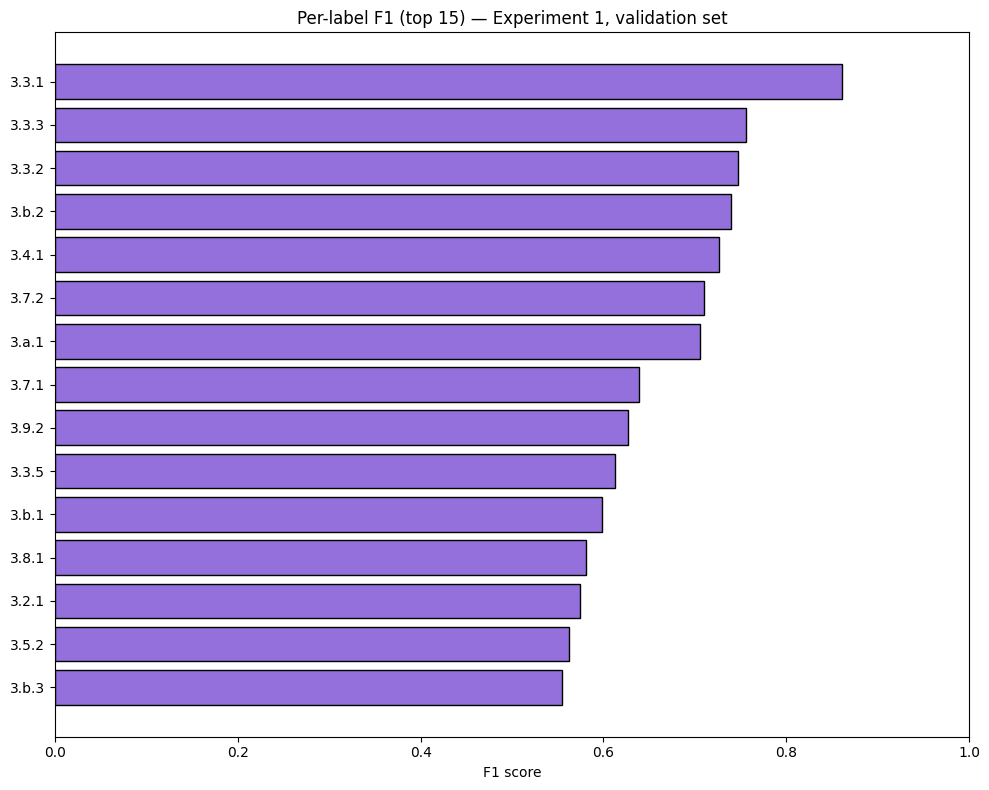

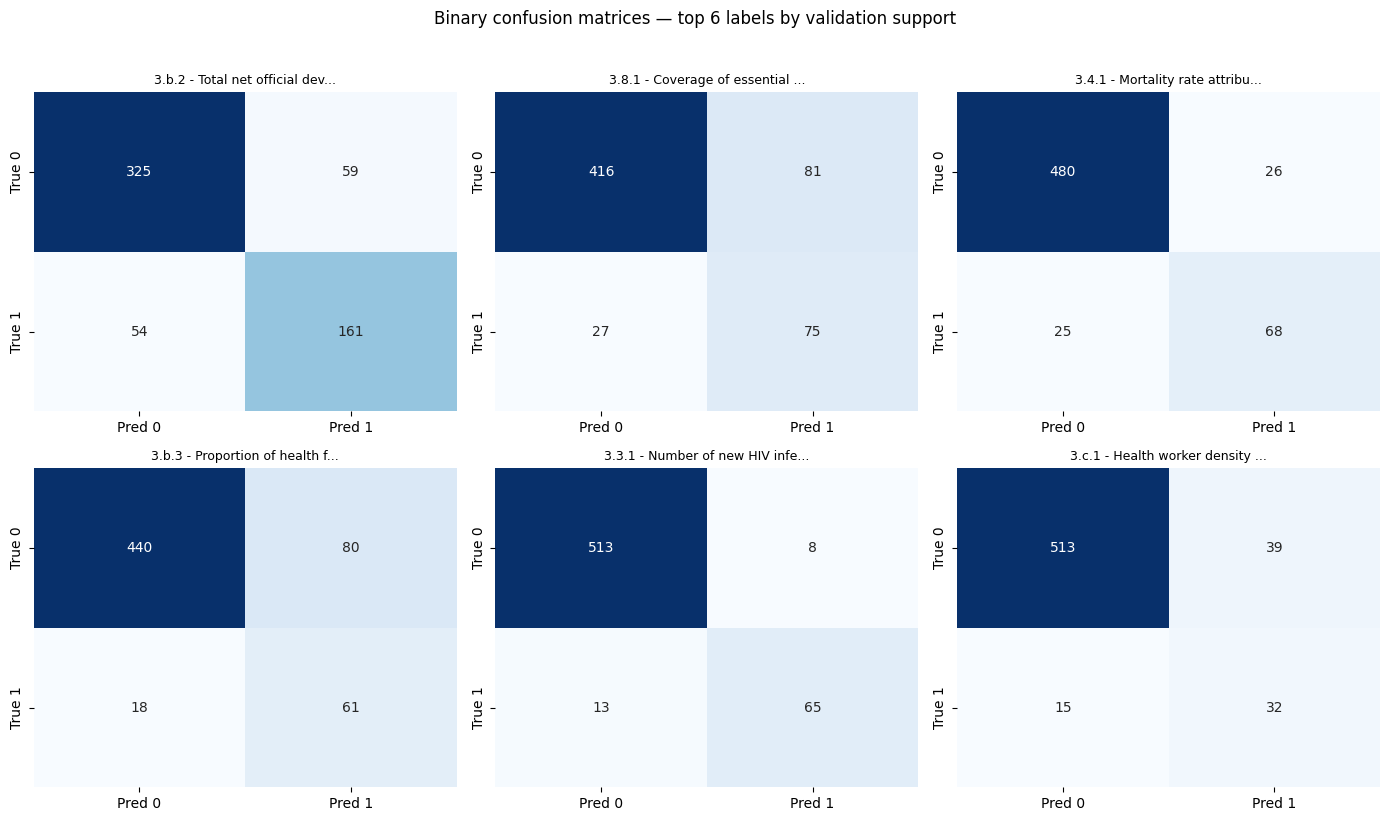

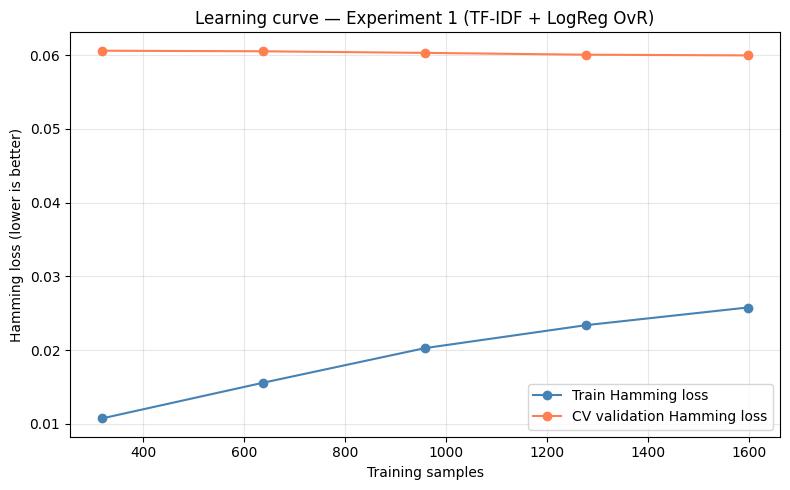

Learning curve summary:
  n= 319  train HL=0.0108  CV val HL=0.0606
  n= 638  train HL=0.0156  CV val HL=0.0605
  n= 958  train HL=0.0203  CV val HL=0.0603
  n=1277  train HL=0.0234  CV val HL=0.0601
  n=1597  train HL=0.0258  CV val HL=0.0600


,experiment,what_changed,hamming_loss,f1_micro,f1_macro
0,1,"TF-IDF (1–2 grams) + LogReg OvR, best preproce...",0.06146,0.620031,0.549612


In [11]:
def multilabel_report(y_true, y_pred, classes):
    """Build per-label precision/recall/F1/support table."""
    prec = precision_score(y_true, y_pred, average=None, zero_division=0)
    rec = recall_score(y_true, y_pred, average=None, zero_division=0)
    f1 = f1_score(y_true, y_pred, average=None, zero_division=0)
    support = y_true.sum(axis=0)
    df = pd.DataFrame({
        "indicator": classes,
        "precision": prec.round(3),
        "recall": rec.round(3),
        "f1": f1.round(3),
        "support": support.astype(int),
    }).sort_values("f1", ascending=False)
    return df


report_df = multilabel_report(y_val, y_val_pred, label_names)
print("Multi-label classification report — Experiment 1 (validation):\n")
display(report_df)

# Sklearn-style text summary for top labels
print(classification_report(
    y_val, y_val_pred,
    target_names=[n[:40] for n in label_names],
    zero_division=0,
))

# Per-label F1 bar chart (top 15)
fig, ax = plt.subplots(figsize=(10, 8))
plot_df = report_df.head(15).iloc[::-1]
short_names = plot_df["indicator"].str.replace(r"^(\d+\.\S+) - .*", r"\1", regex=True)
ax.barh(short_names, plot_df["f1"], color="mediumpurple", edgecolor="black")
ax.set_xlim(0, 1)
ax.set_xlabel("F1 score")
ax.set_title("Per-label F1 (top 15) — Experiment 1, validation set")
plt.tight_layout()
plt.show()

# Confusion matrices for top 6 labels by support
top6_idx = np.argsort(y_val.sum(axis=0))[::-1][:6]
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
mcm = multilabel_confusion_matrix(y_val, y_val_pred)
for ax, li in zip(axes.ravel(), top6_idx):
    tn, fp, fn, tp = mcm[li].ravel()
    sns.heatmap(
        np.array([[tn, fp], [fn, tp]]),
        annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax,
        xticklabels=["Pred 0", "Pred 1"], yticklabels=["True 0", "True 1"],
    )
    short = label_names[li][:30] + ("..." if len(label_names[li]) > 30 else "")
    ax.set_title(short, fontsize=9)
fig.suptitle("Binary confusion matrices — top 6 labels by validation support", y=1.02)
plt.tight_layout()
plt.show()

# Learning curve (Hamming loss) — use fractions so sizes respect CV fold limits
train_sizes = np.linspace(0.2, 1.0, 5)

def hamming_scorer(estimator, X, y_true):
    return -hamming_loss(y_true, estimator.predict(X))

lc_estimator = OneVsRestClassifier(
    LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE)
)
train_sz, train_scores, val_scores = learning_curve(
    lc_estimator, X_train_tfidf, y_train,
    train_sizes=train_sizes, cv=3, scoring=hamming_scorer, n_jobs=-1,
)
train_hl = -train_scores.mean(axis=1)
val_hl = -val_scores.mean(axis=1)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(train_sz, train_hl, "o-", label="Train Hamming loss", color="steelblue")
ax.plot(train_sz, val_hl, "o-", label="CV validation Hamming loss", color="coral")
ax.set_xlabel("Training samples")
ax.set_ylabel("Hamming loss (lower is better)")
ax.set_title("Learning curve — Experiment 1 (TF-IDF + LogReg OvR)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
os.makedirs("results", exist_ok=True)
fig.savefig("results/experiment1_learning_curve.png", dpi=150)
plt.show()

print("Learning curve summary:")
for n, tr, va in zip(train_sz, train_hl, val_hl):
    print(f"  n={int(n):4d}  train HL={tr:.4f}  CV val HL={va:.4f}")

# Experiment tracking table (STEP 8 runs experiments 1–10 and replaces this)
experiments = pd.DataFrame([
    {
        "experiment": 1,
        "what_changed": "TF-IDF (1–2 grams) + LogReg OvR, best preprocessing",
        "hamming_loss": val_hamming,
        "f1_micro": val_f1_micro,
        "f1_macro": val_f1_macro,
    }
])
display(experiments)


## STEP 7: Train on full data + generate test predictions

Retrain the best baseline on all training samples, predict on test set, and export a submission CSV.

In [12]:
def binary_preds_to_label_columns(y_binary, classes, n_slots=12):
    """Convert binary prediction matrix to Label 1..Label n columns (NA-padded)."""
    rows = []
    for row in y_binary:
        active = [classes[i] for i, v in enumerate(row) if v == 1]
        padded = active + ["NA"] * (n_slots - len(active))
        rows.append(padded[:n_slots])
    cols = [f"Label {i}" for i in range(1, n_slots + 1)]
    return pd.DataFrame(rows, columns=cols)


# Retrain on full training set
X_full_tfidf = vectorizer.fit_transform(train_df["clean_text"])
final_model = OneVsRestClassifier(
    LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE)
)
final_model.fit(X_full_tfidf, y)

X_test_tfidf = vectorizer.transform(test_df["clean_text"])
y_test_pred = final_model.predict(X_test_tfidf)

label_preds = binary_preds_to_label_columns(y_test_pred, label_names)

submission = pd.concat(
    [test_df[["Unique ID", "Type", "Text"]].reset_index(drop=True), label_preds],
    axis=1,
)

OUTPUT_PATH = "Devex_test_predictions.csv"
submission.to_csv(OUTPUT_PATH, index=False)

print(f"Test predictions saved to: {OUTPUT_PATH}")
print(f"Predicted labels per test row — mean: {y_test_pred.sum(axis=1).mean():.2f}")
display(submission.head(3))

Test predictions saved to: Devex_test_predictions.csv
Predicted labels per test row — mean: 2.47


,Unique ID,Type,Text,Label 1,Label 2,Label 3,Label 4,Label 5,Label 6,Label 7,Label 8,Label 9,Label 10,Label 11,Label 12
0,49848,Organization,4th Sector Health: <p>4th Sector Health is a U...,3.8.1 - Coverage of essential health services ...,3.8.2 - Proportion of population with large ho...,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
1,52348,Organization,Action for Global Health: <p>Action for Global...,3.1.1 - Maternal mortality ratio,"3.3.1 - Number of new HIV infections per 1,000...","3.3.3 - Malaria incidence per 1,000 population",3.8.1 - Coverage of essential health services ...,3.8.2 - Proportion of population with large ho...,NA,NA,NA,NA,NA,NA,NA
2,103541,Organization,Scottish Association for Mental Health (SAMH):...,3.4.2 - Suicide mortality rate,3.5.1 - Coverage of treatment interventions (p...,3.8.1 - Coverage of essential health services ...,3.8.2 - Proportion of population with large ho...,NA,NA,NA,NA,NA,NA,NA,NA


## STEP 8: Model & feature experiments (1–10)

Each experiment changes **one factor** while holding others at the baseline (best preprocessing from STEP 4, TF-IDF 15k, LogReg OvR unless noted).

**Metrics:** Hamming loss (primary), F1 micro/macro (secondary).


### Experiments 1–4: Baseline, metadata, n-grams, raw text

| Exp | Change | Rationale |
|-----|--------|-----------|
| **1** | Baseline TF-IDF + LogReg | Reference point after preprocessing ablation |
| **2** | Prepend document Type | Grants/Tenders/News may use different vocabulary per indicator |
| **3** | Unigrams only | Tests whether bigrams add signal or noise |
| **4** | Raw text (no HTML clean) | Confirms preprocessing ablation — expect worse Hamming loss |


In [13]:
def run_experiment(exp_id, text_series, vectorizer_kwargs, estimator, threshold=0.5):
    """Train/evaluate one multi-label config; return metrics dict."""
    idx = np.arange(len(text_series))
    idx_train, idx_val = train_test_split(idx, test_size=TEST_SIZE, random_state=RANDOM_STATE)

    X_tr = text_series.iloc[idx_train]
    X_va = text_series.iloc[idx_val]
    y_tr = y[idx_train]
    y_va = y[idx_val]

    vec = TfidfVectorizer(**vectorizer_kwargs)
    X_tr_vec = vec.fit_transform(X_tr)
    X_va_vec = vec.transform(X_va)

    clf = OneVsRestClassifier(estimator)
    clf.fit(X_tr_vec, y_tr)

    if threshold != 0.5 and hasattr(clf, "predict_proba"):
        y_pred = (clf.predict_proba(X_va_vec) >= threshold).astype(int)
    elif threshold != 0.5 and hasattr(clf, "decision_function"):
        y_pred = (clf.decision_function(X_va_vec) >= threshold).astype(int)
    else:
        y_pred = clf.predict(X_va_vec)

    return {
        "experiment": exp_id,
        "hamming_loss": hamming_loss(y_va, y_pred),
        "f1_micro": f1_score(y_va, y_pred, average="micro", zero_division=0),
        "f1_macro": f1_score(y_va, y_pred, average="macro", zero_division=0),
        "avg_labels_pred": y_pred.sum(axis=1).mean(),
        "n_features": X_tr_vec.shape[1],
    }


BASE_VEC = dict(max_features=15000, ngram_range=(1, 2), min_df=2, stop_words="english")
LOGREG = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE)
LOGREG_NO_WEIGHT = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
SVC = LinearSVC(class_weight="balanced", random_state=RANDOM_STATE)

experiment_configs = [
    {"id": 1, "text": train_df["clean_text"], "vec": BASE_VEC,
     "estimator": LOGREG, "threshold": 0.5,
     "what_changed": "TF-IDF (1–2 grams, 15k) + LogReg OvR, best preprocessing",
     "text_mode": "clean", "model": "LogReg", "features": "TF-IDF 15k"},
    {"id": 2, "text": train_df["Type"].astype(str) + " : " + train_df["clean_text"], "vec": BASE_VEC,
     "estimator": LOGREG, "threshold": 0.5,
     "what_changed": "Prepend document Type (Grant/Tender/News)",
     "text_mode": "type_clean", "model": "LogReg", "features": "TF-IDF 15k + Type"},
    {"id": 3, "text": train_df["clean_text"], "vec": {**BASE_VEC, "ngram_range": (1, 1)},
     "estimator": LOGREG, "threshold": 0.5,
     "what_changed": "Unigrams only (no bigrams)",
     "text_mode": "clean", "model": "LogReg", "features": "TF-IDF unigrams"},
    {"id": 4, "text": train_df["Text"].astype(str), "vec": BASE_VEC,
     "estimator": LOGREG, "threshold": 0.5,
     "what_changed": "Raw text, no HTML cleaning",
     "text_mode": "raw", "model": "LogReg", "features": "TF-IDF 15k"},
]

results = []
for cfg in experiment_configs:
    metrics = run_experiment(cfg["id"], cfg["text"], cfg["vec"], cfg["estimator"], cfg["threshold"])
    metrics.update({k: cfg[k] for k in ("what_changed", "model", "features")})
    results.append(metrics)
    print(f"Experiment {cfg['id']}: {cfg['what_changed']}")
    print(f"  Hamming loss: {metrics['hamming_loss']:.4f} | F1 micro: {metrics['f1_micro']:.4f}\n")


Experiment 1: TF-IDF (1–2 grams, 15k) + LogReg OvR, best preprocessing
  Hamming loss: 0.0615 | F1 micro: 0.6200

Experiment 2: Prepend document Type (Grant/Tender/News)
  Hamming loss: 0.0607 | F1 micro: 0.6263

Experiment 3: Unigrams only (no bigrams)
  Hamming loss: 0.0607 | F1 micro: 0.6223

Experiment 4: Raw text, no HTML cleaning
  Hamming loss: 0.0691 | F1 micro: 0.5881



### Experiment 5: Decision threshold

**What changed:** Lower probability threshold from 0.5 → 0.35.

**Why:** Baseline predicts ~2.4 labels/doc vs. ~2.0 true mean — threshold tuning may improve recall on rare labels.

**How Exp 1–4 informed this:** Exp 1–3 had similar Hamming loss; we next test whether calibration/threshold affects multi-label predictions before switching classifiers.


In [14]:
cfg5 = {"id": 5, "text": train_df["clean_text"], "vec": BASE_VEC,
          "estimator": LOGREG, "threshold": 0.35,
          "what_changed": "LogReg with probability threshold 0.35",
          "text_mode": "clean", "model": "LogReg", "features": "TF-IDF 15k"}
m5 = run_experiment(cfg5["id"], cfg5["text"], cfg5["vec"], cfg5["estimator"], cfg5["threshold"])
m5.update({k: cfg5[k] for k in ("what_changed", "model", "features")})
results.append(m5)
print(f"Experiment 5: {cfg5['what_changed']}")
print(f"  Hamming loss: {m5['hamming_loss']:.4f} | F1 micro: {m5['f1_micro']:.4f}\n")


Experiment 5: LogReg with probability threshold 0.35
  Hamming loss: 0.1038 | F1 micro: 0.5345



### Experiments 6–8: Classifier & feature combinations

**What changed:** Swap LogReg for LinearSVC (Exp 6); combine best metadata feature (Type, Exp 2) with best classifier (Exp 6).

**Why:** LinearSVC often outperforms LogReg on high-dimensional sparse TF-IDF. Exp 2 showed Type prefix helps slightly — Exp 8 combines both wins.

**How Exp 5 informed this:** Threshold tuning hurt Hamming loss (over-prediction), so we pivot to a stronger linear classifier instead.


In [15]:
for cfg in [
    {"id": 6, "text": train_df["clean_text"], "vec": BASE_VEC,
     "estimator": SVC, "threshold": 0.0,
     "what_changed": "LinearSVC instead of LogReg",
     "text_mode": "clean", "model": "LinearSVC", "features": "TF-IDF 15k"},
    {"id": 7, "text": train_df["clean_text"], "vec": {**BASE_VEC, "max_df": 0.85},
     "estimator": LOGREG, "threshold": 0.5,
     "what_changed": "Drop terms in >85% of documents (max_df=0.85)",
     "text_mode": "clean", "model": "LogReg", "features": "TF-IDF + max_df"},
    {"id": 8, "text": train_df["Type"].astype(str) + " : " + train_df["clean_text"], "vec": BASE_VEC,
     "estimator": SVC, "threshold": 0.0,
     "what_changed": "LinearSVC + Type prefix (combine Exp 2 & 6)",
     "text_mode": "type_clean", "model": "LinearSVC", "features": "TF-IDF + Type"},
]:
    metrics = run_experiment(cfg["id"], cfg["text"], cfg["vec"], cfg["estimator"], cfg["threshold"])
    metrics.update({k: cfg[k] for k in ("what_changed", "model", "features")})
    results.append(metrics)
    print(f"Experiment {cfg['id']}: {cfg['what_changed']}")
    print(f"  Hamming loss: {metrics['hamming_loss']:.4f} | F1 micro: {metrics['f1_micro']:.4f}\n")


Experiment 6: LinearSVC instead of LogReg
  Hamming loss: 0.0521 | F1 micro: 0.6359

Experiment 7: Drop terms in >85% of documents (max_df=0.85)
  Hamming loss: 0.0615 | F1 micro: 0.6200

Experiment 8: LinearSVC + Type prefix (combine Exp 2 & 6)
  Hamming loss: 0.0520 | F1 micro: 0.6361



### Experiments 9–10: Class imbalance & vocabulary size

**What changed:** Exp 9 removes `class_weight='balanced'`; Exp 10 increases TF-IDF vocabulary to 25k.

**Why:** STEP 3 imbalance analysis showed 20×+ ratio between frequent/rare labels — Exp 9 tests whether balanced weights are necessary. Exp 10 checks if a larger vocabulary captures rare-indicator terms.

**How Exp 6–8 informed this:** After classifier and feature tweaks (Exps 6–8), we isolate the two remaining levers suggested by EDA: explicit imbalance handling (Exp 9) and vocabulary coverage for rare indicators (Exp 10).


In [16]:
for cfg in [
    {"id": 9, "text": train_df["clean_text"], "vec": BASE_VEC,
     "estimator": LOGREG_NO_WEIGHT, "threshold": 0.5,
     "what_changed": "LogReg without class_weight=balanced",
     "text_mode": "clean", "model": "LogReg (no weight)", "features": "TF-IDF 15k"},
    {"id": 10, "text": train_df["clean_text"], "vec": {**BASE_VEC, "max_features": 25000},
     "estimator": LOGREG, "threshold": 0.5,
     "what_changed": "Increase TF-IDF vocabulary to 25k features",
     "text_mode": "clean", "model": "LogReg", "features": "TF-IDF 25k"},
]:
    metrics = run_experiment(cfg["id"], cfg["text"], cfg["vec"], cfg["estimator"], cfg["threshold"])
    metrics.update({k: cfg[k] for k in ("what_changed", "model", "features")})
    results.append(metrics)
    print(f"Experiment {cfg['id']}: {cfg['what_changed']}")
    print(f"  Hamming loss: {metrics['hamming_loss']:.4f} | F1 micro: {metrics['f1_micro']:.4f}\n")

experiment_configs = experiment_configs + [cfg5] + [
    {"id": 6, "text": train_df["clean_text"], "vec": BASE_VEC, "estimator": SVC, "threshold": 0.0,
     "what_changed": "LinearSVC instead of LogReg", "text_mode": "clean", "model": "LinearSVC", "features": "TF-IDF 15k"},
    {"id": 7, "text": train_df["clean_text"], "vec": {**BASE_VEC, "max_df": 0.85}, "estimator": LOGREG, "threshold": 0.5,
     "what_changed": "Drop terms in >85% of documents (max_df=0.85)", "text_mode": "clean", "model": "LogReg", "features": "TF-IDF + max_df"},
    {"id": 8, "text": train_df["Type"].astype(str) + " : " + train_df["clean_text"], "vec": BASE_VEC, "estimator": SVC, "threshold": 0.0,
     "what_changed": "LinearSVC + Type prefix (combine Exp 2 & 6)", "text_mode": "type_clean", "model": "LinearSVC", "features": "TF-IDF + Type"},
    {"id": 9, "text": train_df["clean_text"], "vec": BASE_VEC, "estimator": LOGREG_NO_WEIGHT, "threshold": 0.5,
     "what_changed": "LogReg without class_weight=balanced", "text_mode": "clean", "model": "LogReg (no weight)", "features": "TF-IDF 15k"},
    {"id": 10, "text": train_df["clean_text"], "vec": {**BASE_VEC, "max_features": 25000}, "estimator": LOGREG, "threshold": 0.5,
     "what_changed": "Increase TF-IDF vocabulary to 25k features", "text_mode": "clean", "model": "LogReg", "features": "TF-IDF 25k"},
]

experiments = pd.DataFrame(results).sort_values("experiment")
print("All experiments ranked by Hamming loss:")
display(experiments.sort_values("hamming_loss"))


Experiment 9: LogReg without class_weight=balanced
  Hamming loss: 0.0555 | F1 micro: 0.4191

Experiment 10: Increase TF-IDF vocabulary to 25k features
  Hamming loss: 0.0607 | F1 micro: 0.6208

All experiments ranked by Hamming loss:


,experiment,hamming_loss,f1_micro,f1_macro,avg_labels_pred,n_features,what_changed,model,features
7,8,0.052000,0.636088,0.565694,1.906511,15000,LinearSVC + Type prefix (combine Exp 2 & 6),LinearSVC,TF-IDF + Type
5,6,0.052124,0.635853,0.564239,1.913189,15000,LinearSVC instead of LogReg,LinearSVC,TF-IDF 15k
8,9,0.055525,0.419146,0.247449,0.629382,15000,LogReg without class_weight=balanced,LogReg (no weight),TF-IDF 15k
2,3,0.060657,0.622256,0.548113,2.383973,14239,Unigrams only (no bigrams),LogReg,TF-IDF unigrams
9,10,0.060657,0.620796,0.549298,2.367279,25000,Increase TF-IDF vocabulary to 25k features,LogReg,TF-IDF 25k
1,2,0.060718,0.626332,0.553988,2.435726,15000,Prepend document Type (Grant/Tender/News),LogReg,TF-IDF 15k + Type
6,7,0.061460,0.620031,0.549612,2.415693,15000,Drop terms in >85% of documents (max_df=0.85),LogReg,TF-IDF + max_df
0,1,0.061460,0.620031,0.549612,2.415693,15000,"TF-IDF (1–2 grams, 15k) + LogReg OvR, best pre...",LogReg,TF-IDF 15k
3,4,0.069128,0.588062,0.508335,2.579299,15000,"Raw text, no HTML cleaning",LogReg,TF-IDF 15k
4,5,0.103815,0.534516,0.479406,4.070117,15000,LogReg with probability threshold 0.35,LogReg,TF-IDF 15k


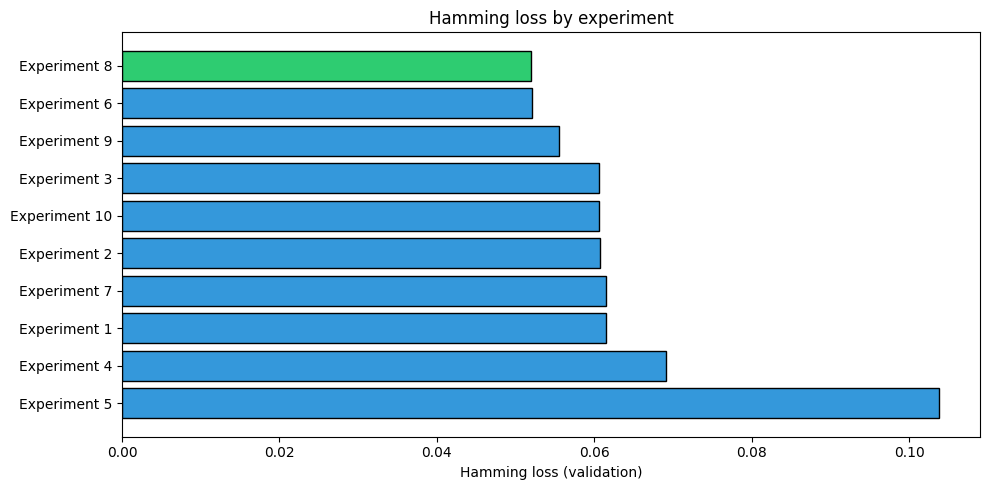

Experiment comparison (sorted by Hamming loss):



,experiment,what_changed,hamming_loss,f1_micro,f1_macro,avg_labels_pred
7,8,LinearSVC + Type prefix (combine Exp 2 & 6),0.052000,0.636088,0.565694,1.906511
5,6,LinearSVC instead of LogReg,0.052124,0.635853,0.564239,1.913189
8,9,LogReg without class_weight=balanced,0.055525,0.419146,0.247449,0.629382
2,3,Unigrams only (no bigrams),0.060657,0.622256,0.548113,2.383973
9,10,Increase TF-IDF vocabulary to 25k features,0.060657,0.620796,0.549298,2.367279
1,2,Prepend document Type (Grant/Tender/News),0.060718,0.626332,0.553988,2.435726
6,7,Drop terms in >85% of documents (max_df=0.85),0.061460,0.620031,0.549612,2.415693
0,1,"TF-IDF (1–2 grams, 15k) + LogReg OvR, best pre...",0.061460,0.620031,0.549612,2.415693
3,4,"Raw text, no HTML cleaning",0.069128,0.588062,0.508335,2.579299
4,5,LogReg with probability threshold 0.35,0.103815,0.534516,0.479406,4.070117



Class imbalance ablation — Exp 1 (balanced) vs Exp 9 (no class_weight):


,experiment,what_changed,hamming_loss,f1_micro,f1_macro
0,1,"TF-IDF (1–2 grams, 15k) + LogReg OvR, best pre...",0.061460,0.620031,0.549612
8,9,LogReg without class_weight=balanced,0.055525,0.419146,0.247449


  Δ Hamming loss (Exp 9 − Exp 1): -0.0059  (no clear benefit from balanced weights)

Best: Experiment 8
  Hamming loss: 0.0520
  F1 micro / macro: 0.6361 / 0.5657
  What changed: LinearSVC + Type prefix (combine Exp 2 & 6)


In [17]:
# Hamming loss comparison (lower is better)
fig, ax = plt.subplots(figsize=(10, 5))
plot_ex = experiments.sort_values("hamming_loss")
labels = [f"Experiment {int(e)}" for e in plot_ex["experiment"]]
colors = ["#2ecc71" if i == 0 else "#3498db" for i in range(len(plot_ex))]
ax.barh(labels, plot_ex["hamming_loss"], color=colors, edgecolor="black")
ax.set_xlabel("Hamming loss (validation)")
ax.set_title("Hamming loss by experiment")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

# Full experiment comparison table (Hamming loss + F1 micro/macro)
comparison_cols = ["experiment", "what_changed", "hamming_loss", "f1_micro", "f1_macro", "avg_labels_pred"]
print("Experiment comparison (sorted by Hamming loss):\n")
display(experiments.sort_values("hamming_loss")[comparison_cols])

# Class imbalance experiment: Exp 1 (balanced) vs Exp 9 (no weight)
imb_cmp = experiments[experiments["experiment"].isin([1, 9])].sort_values("experiment")
if len(imb_cmp) == 2:
    print("\nClass imbalance ablation — Exp 1 (balanced) vs Exp 9 (no class_weight):")
    display(imb_cmp[["experiment", "what_changed", "hamming_loss", "f1_micro", "f1_macro"]])
    delta_hl = imb_cmp.iloc[1]["hamming_loss"] - imb_cmp.iloc[0]["hamming_loss"]
    print(f"  Δ Hamming loss (Exp 9 − Exp 1): {delta_hl:+.4f}  "
          f"({'balanced weights help' if delta_hl > 0 else 'no clear benefit from balanced weights'})")

best = experiments.sort_values("hamming_loss").iloc[0]
print(f"\nBest: Experiment {int(best['experiment'])}")
print(f"  Hamming loss: {best['hamming_loss']:.4f}")
print(f"  F1 micro / macro: {best['f1_micro']:.4f} / {best['f1_macro']:.4f}")
print(f"  What changed: {best['what_changed']}")


### All experiments — learning curves & confusion matrices

To compare configurations visually we generate, for **every experiment (1–10)**:

1. **Learning curves** — CV validation Hamming loss vs. training size, overlaid on one chart plus a 2×5 grid of individual curves
2. **Confusion matrices** — top-6 labels by validation support, saved per experiment (`results/confusion_matrices/exp_01.png` … `exp_10.png`)
3. **F1 heatmap** — per-label F1 across all experiments (rows = experiment, columns = indicator)

Figures are saved under `results/learning_curves/` and `results/confusion_matrices/`. **This cell may take several minutes to run.**

## STEP 9: Final predictions with best experiment

Re-run after STEP 8 to export test predictions using the lowest Hamming-loss configuration.

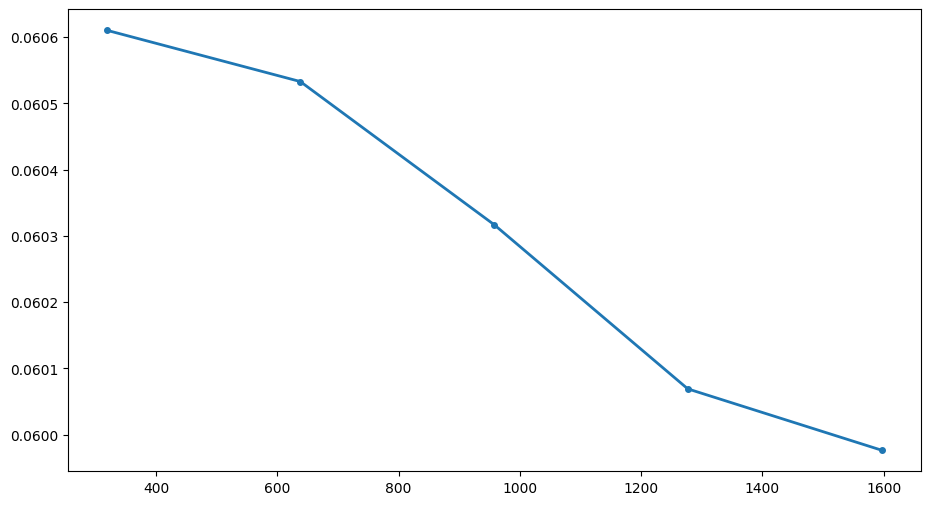

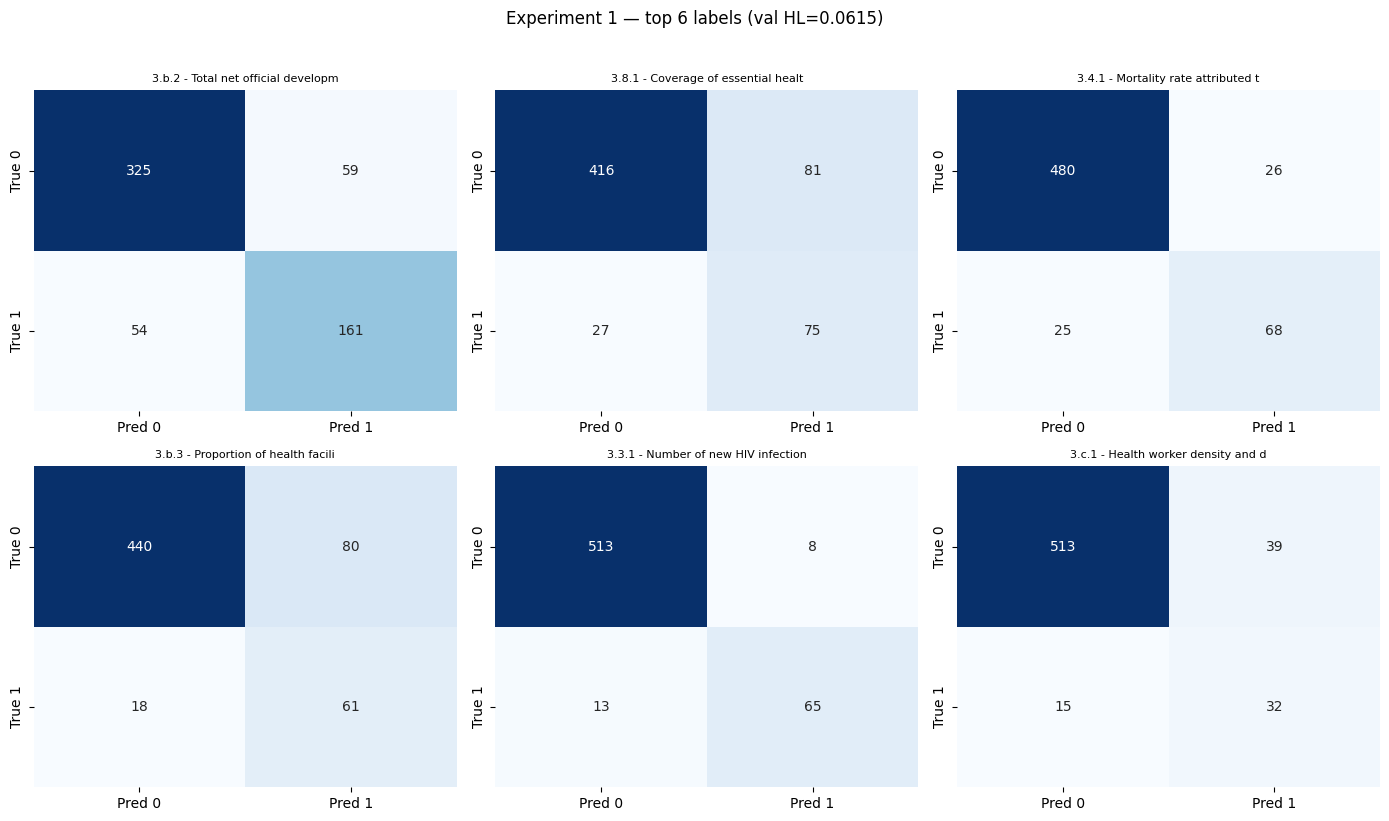

Saved: results/confusion_matrices/exp_01.png


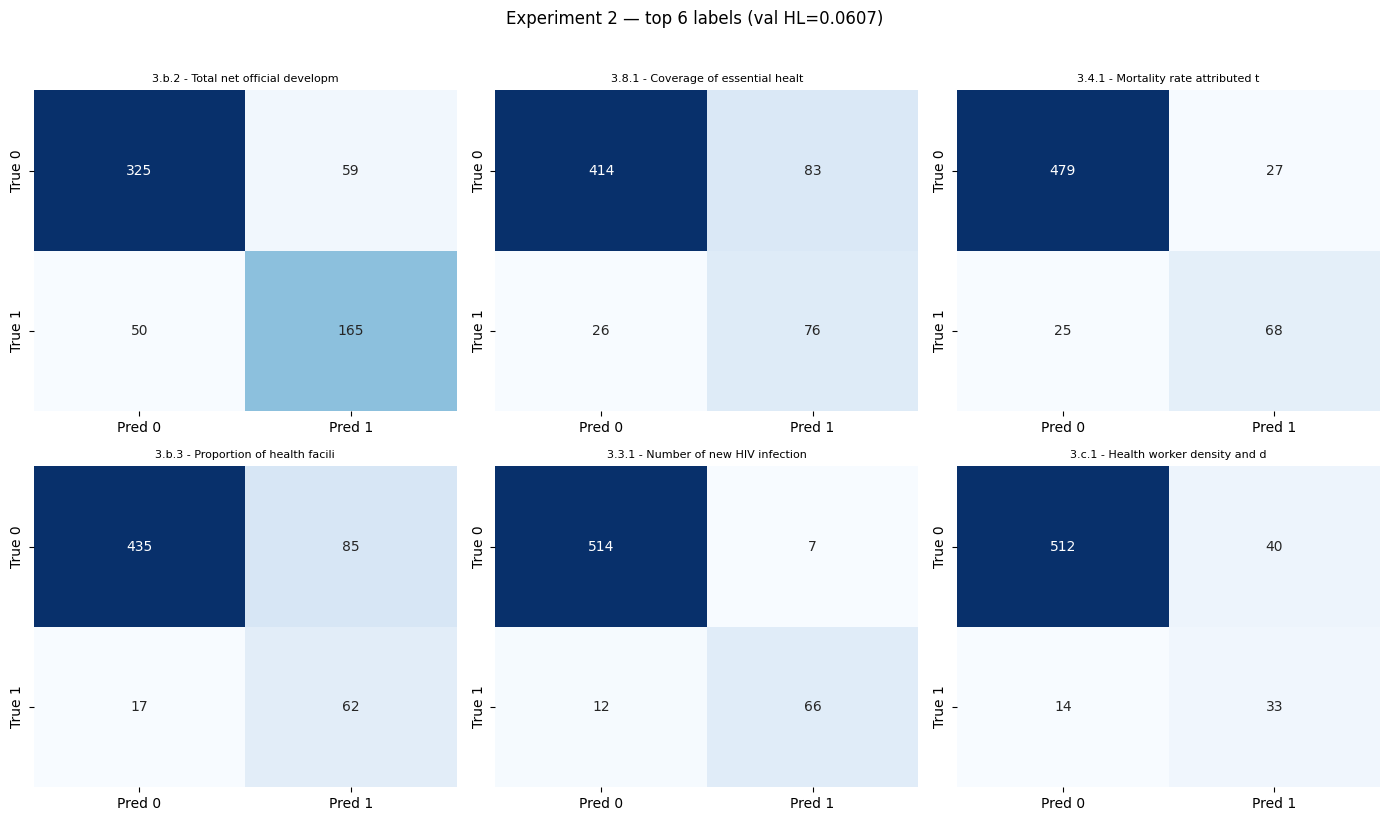

Saved: results/confusion_matrices/exp_02.png


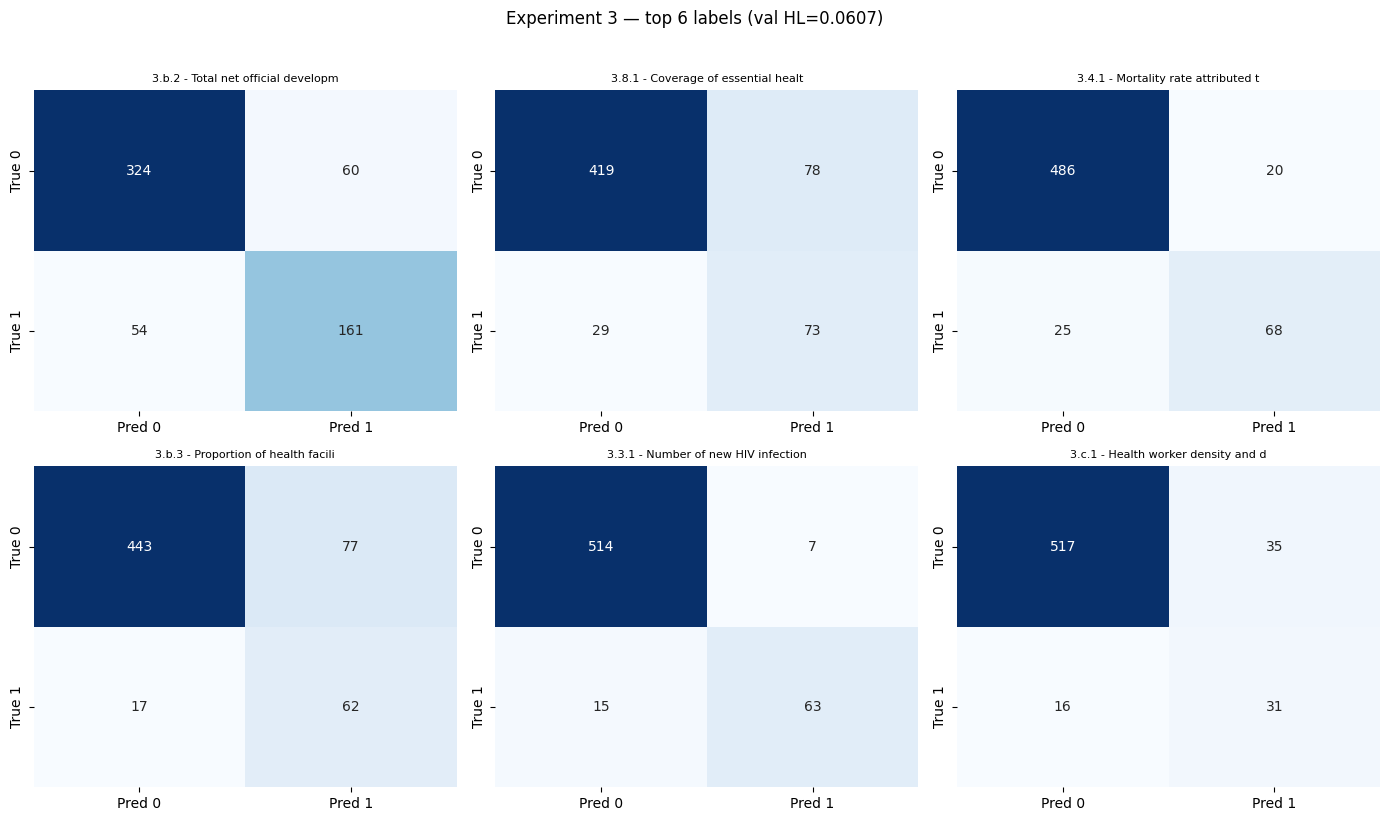

Saved: results/confusion_matrices/exp_03.png


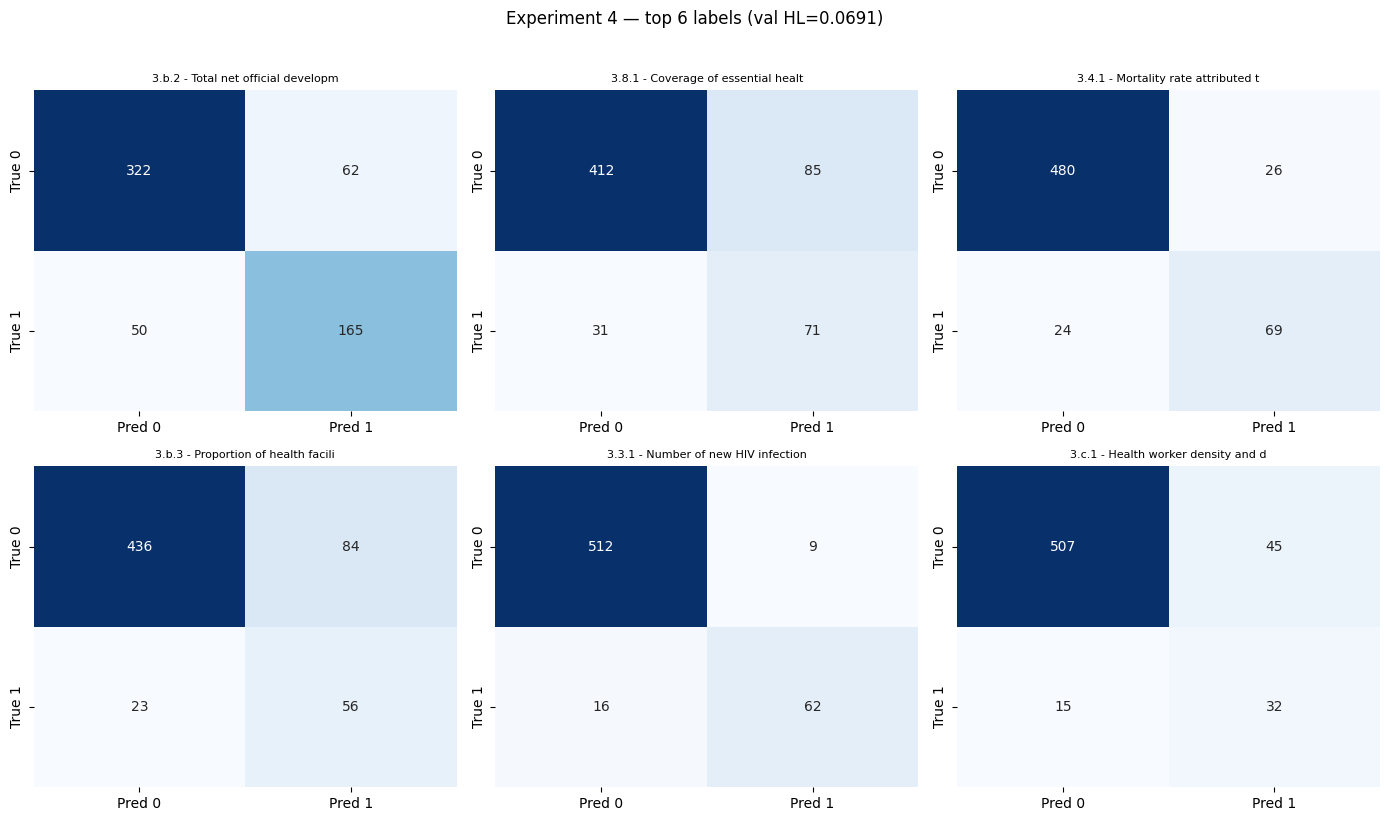

Saved: results/confusion_matrices/exp_04.png


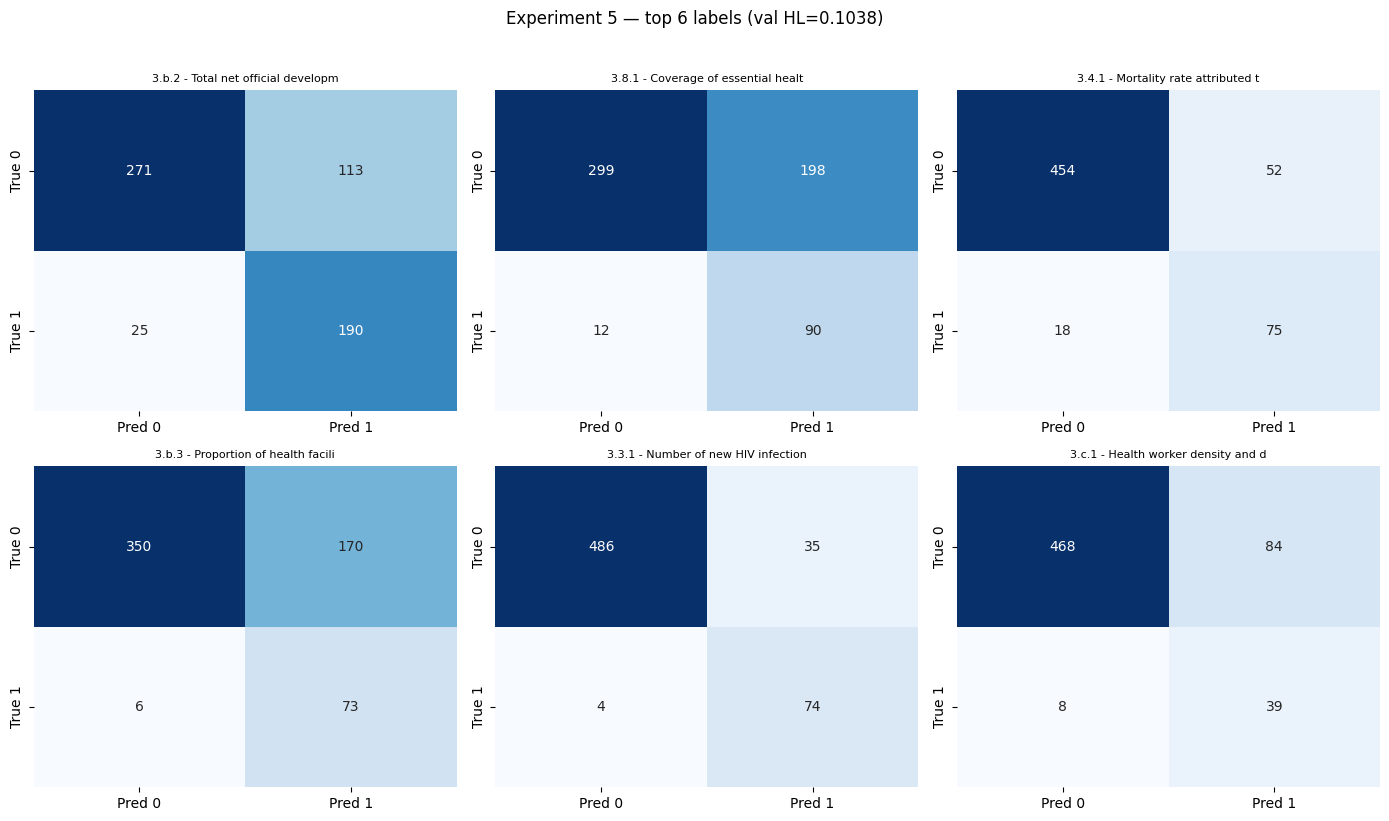

Saved: results/confusion_matrices/exp_05.png


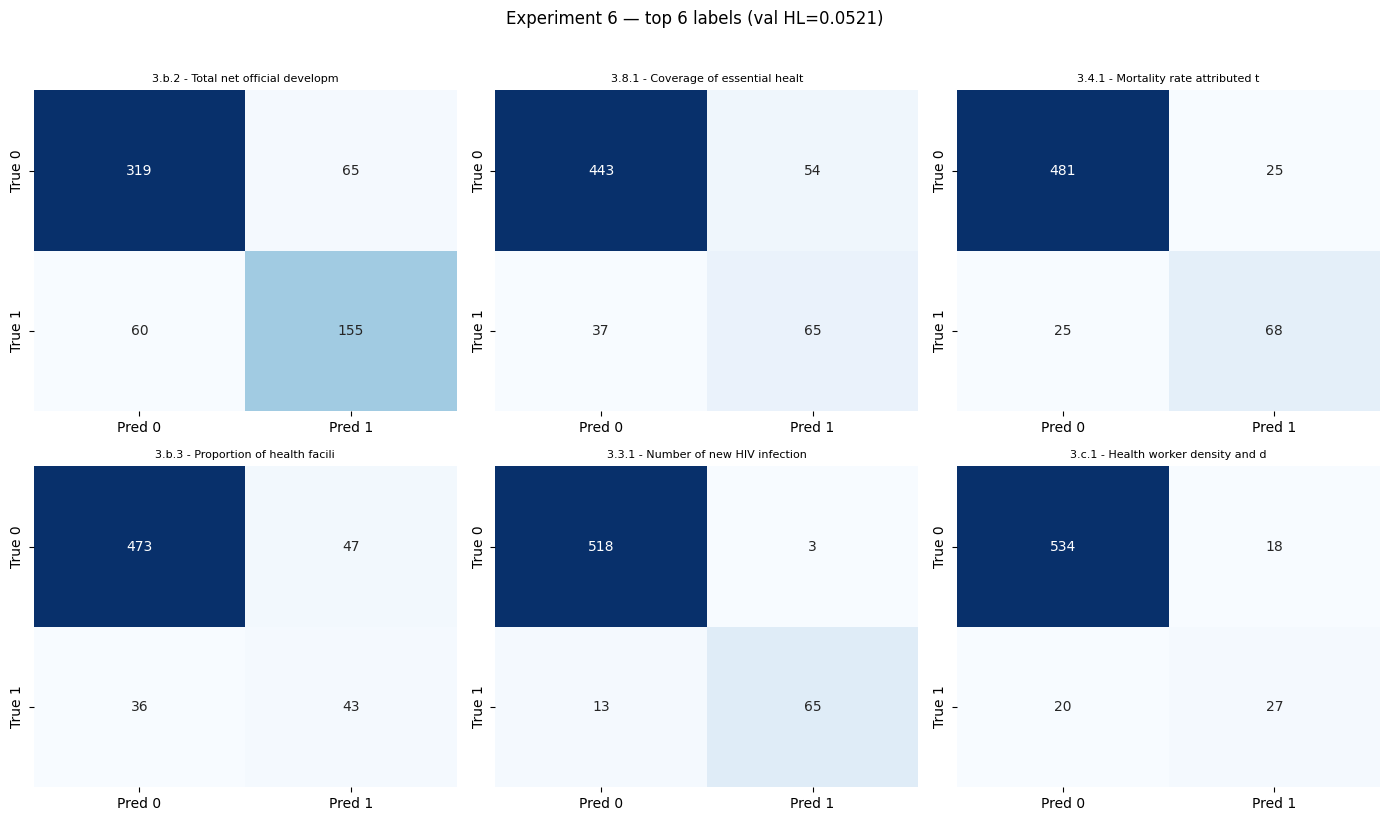

Saved: results/confusion_matrices/exp_06.png


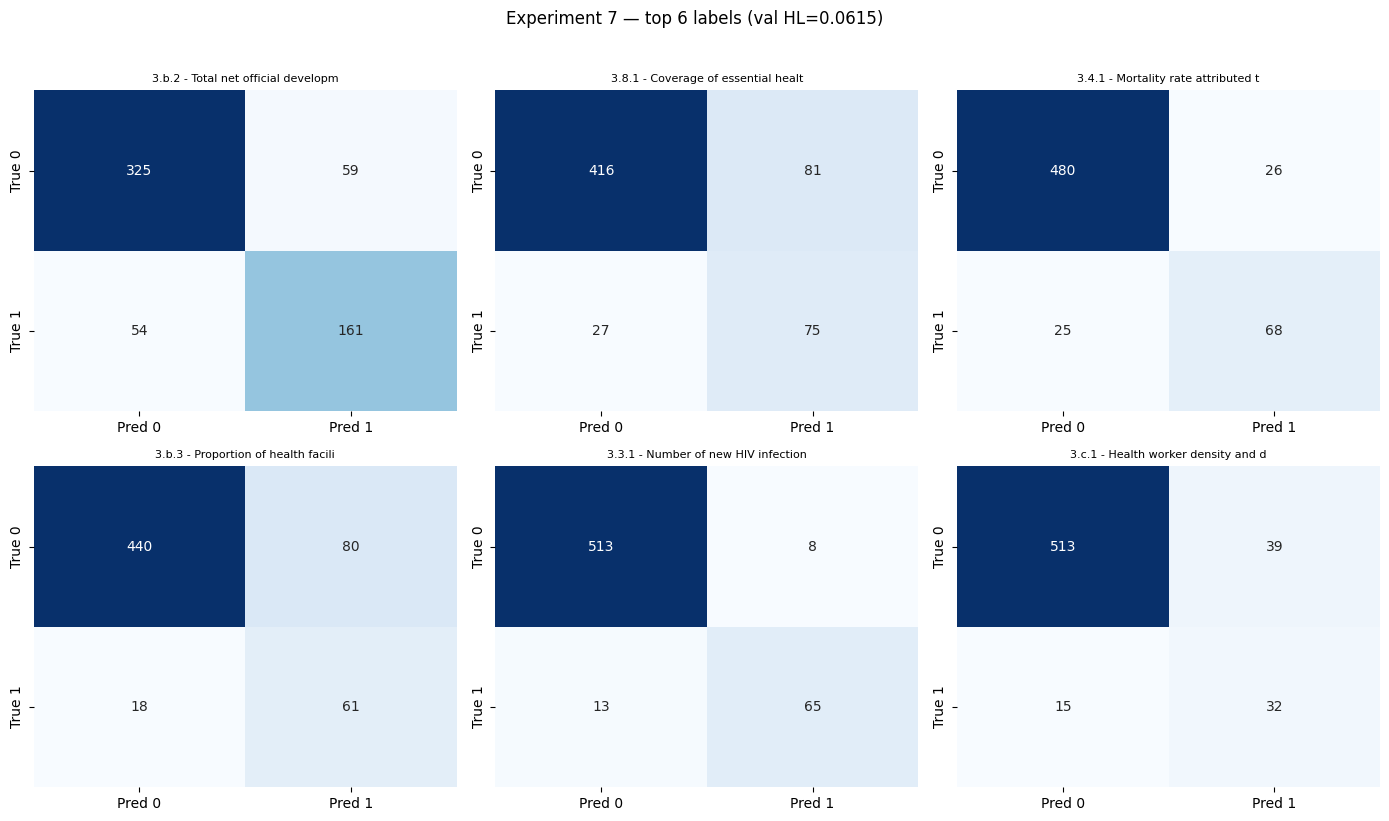

Saved: results/confusion_matrices/exp_07.png


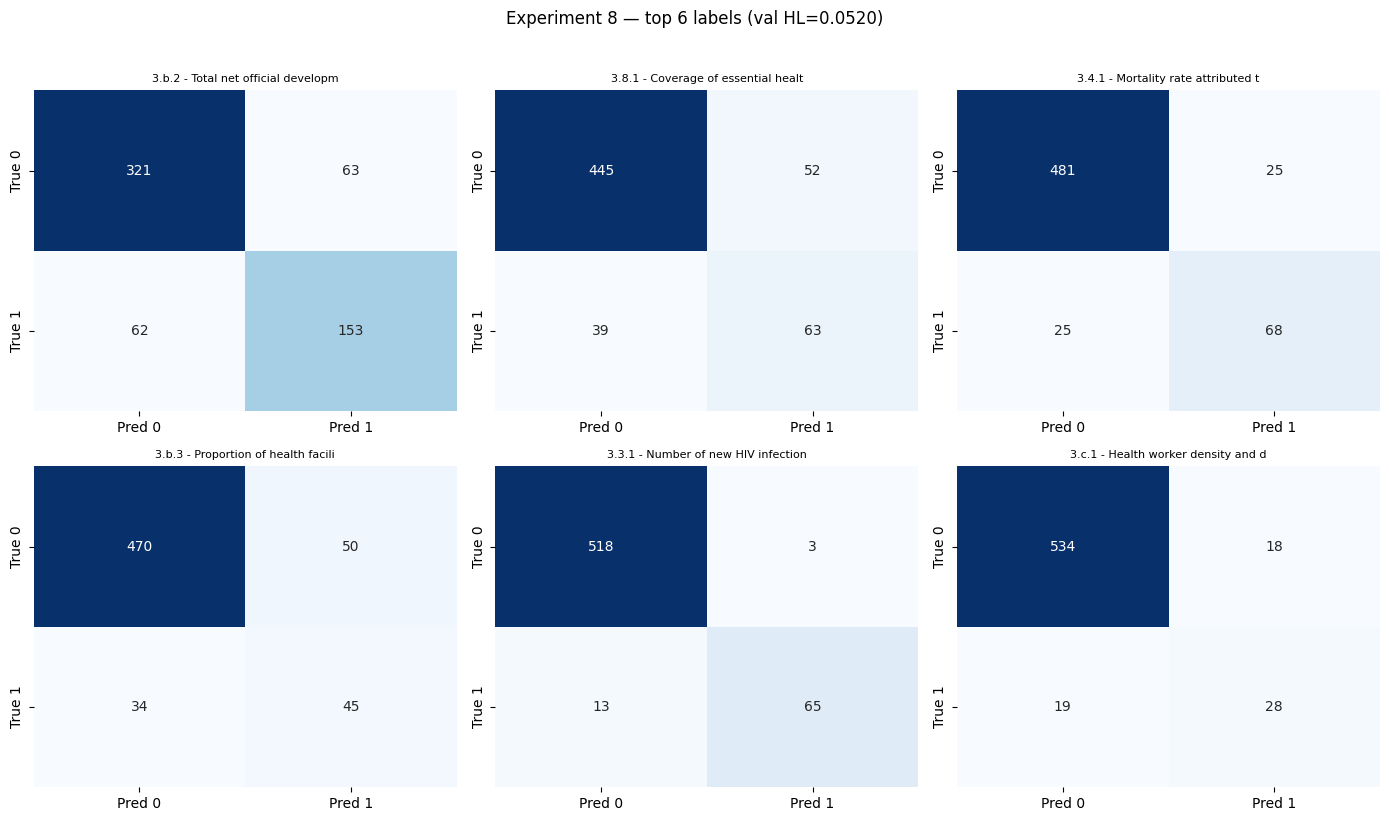

Saved: results/confusion_matrices/exp_08.png


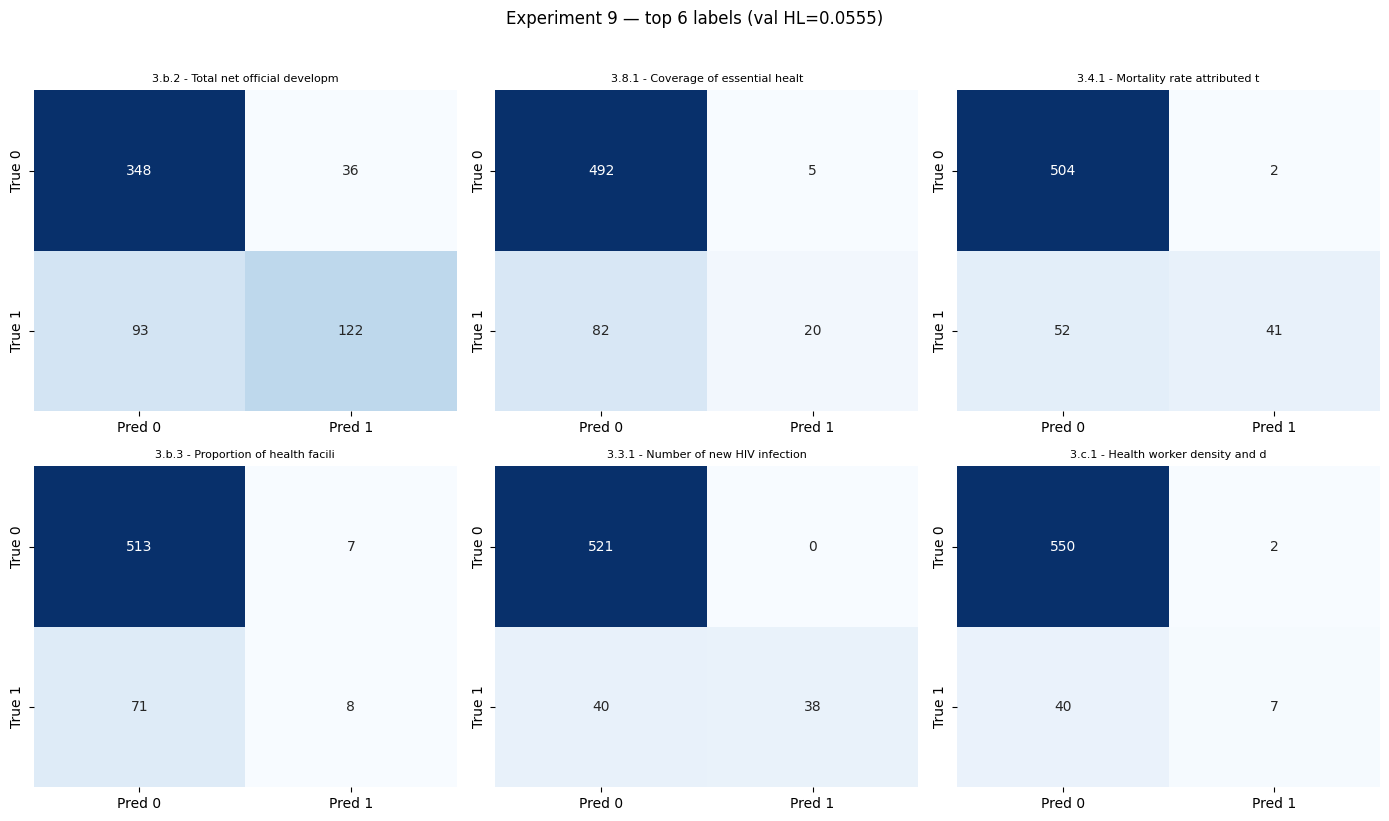

Saved: results/confusion_matrices/exp_09.png


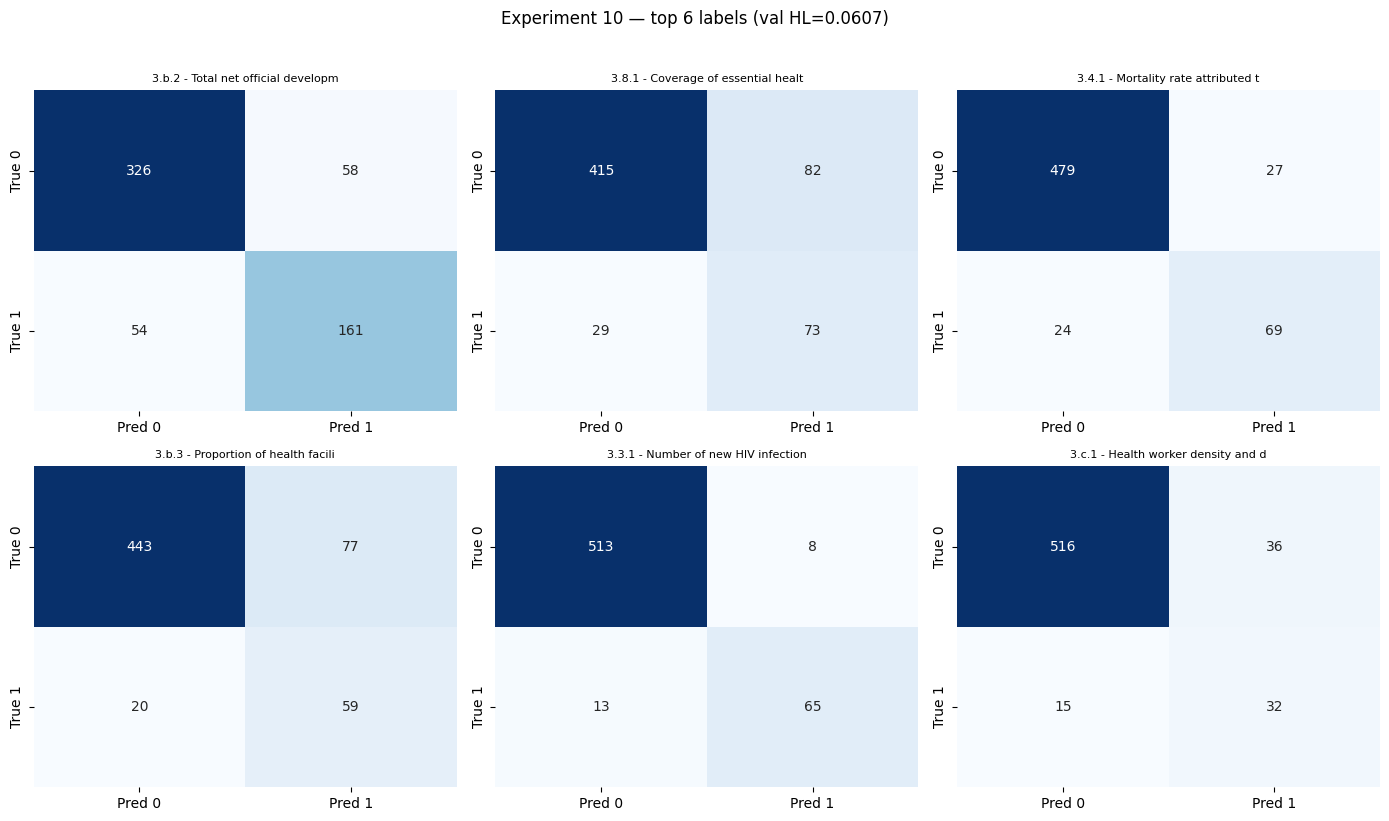

Saved: results/confusion_matrices/exp_10.png


<Figure size 640x480 with 0 Axes>

Saved: results/learning_curves/all_experiments_overlay.png


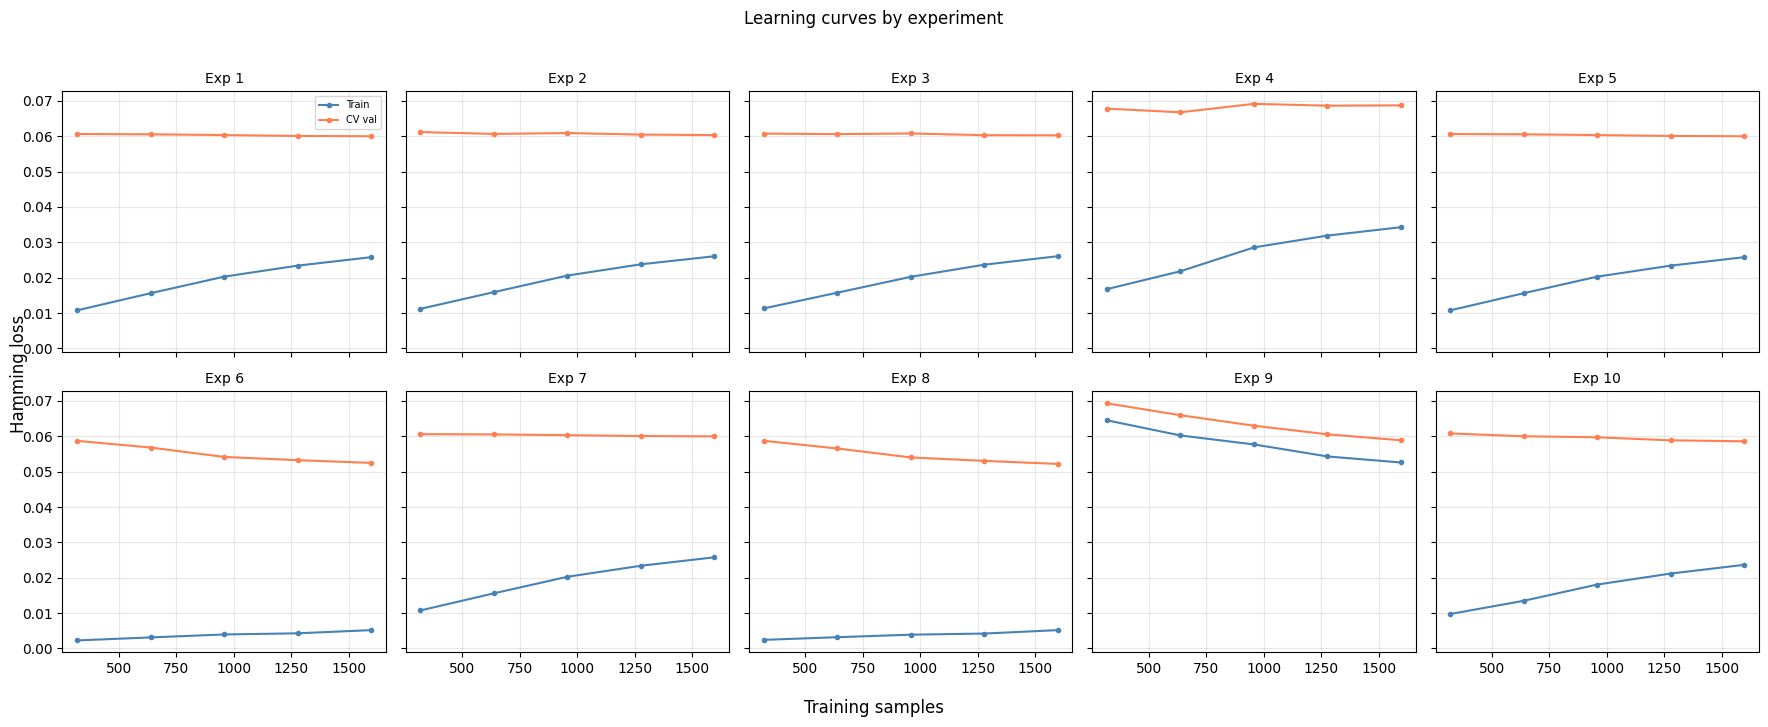

Saved: results/learning_curves/all_experiments_grid.png


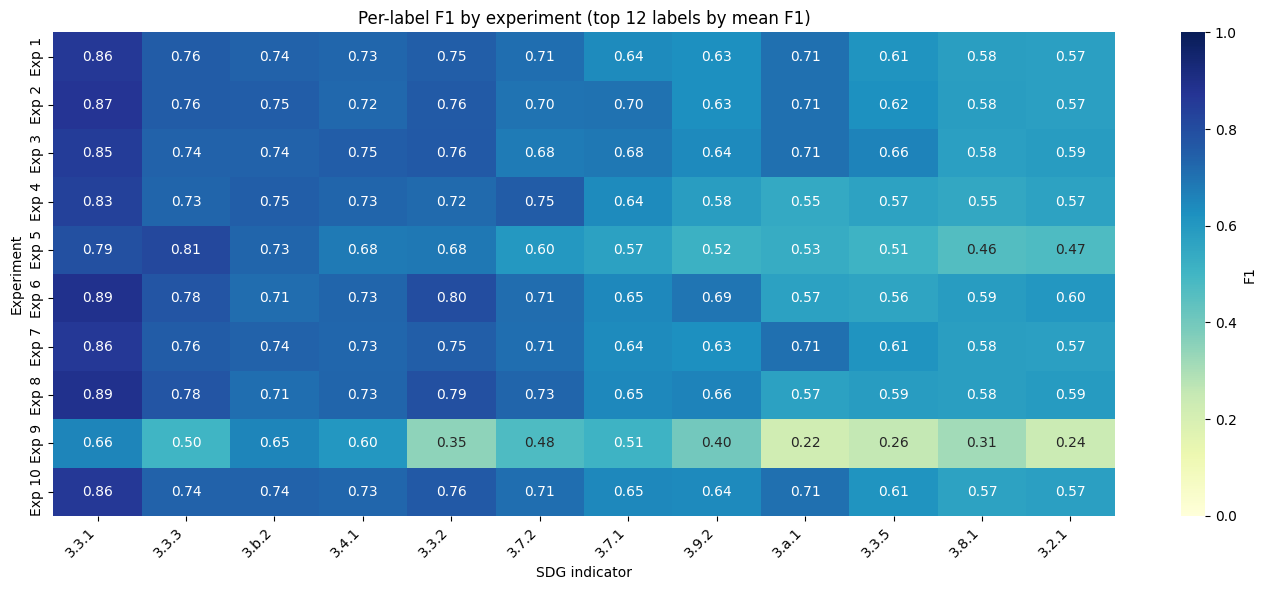

Saved: results/confusion_matrices/f1_heatmap_all_experiments.png


,3.3.1,3.3.3,3.b.2,3.4.1,3.3.2,3.7.2,3.7.1,3.9.2,3.a.1,3.3.5,3.8.1,3.2.1
Exp 1,0.861,0.756,0.740,0.727,0.747,0.710,0.639,0.627,0.706,0.613,0.581,0.574
Exp 2,0.874,0.756,0.752,0.723,0.761,0.698,0.703,0.627,0.706,0.623,0.582,0.574
Exp 3,0.851,0.741,0.739,0.751,0.764,0.677,0.685,0.643,0.706,0.658,0.577,0.589
Exp 4,0.832,0.732,0.747,0.734,0.719,0.754,0.639,0.584,0.545,0.568,0.550,0.568
Exp 5,0.791,0.812,0.734,0.682,0.684,0.600,0.571,0.517,0.533,0.509,0.462,0.474
Exp 6,0.890,0.775,0.713,0.731,0.800,0.712,0.647,0.694,0.571,0.559,0.588,0.602
Exp 7,0.861,0.756,0.740,0.727,0.747,0.710,0.639,0.627,0.706,0.613,0.581,0.574
Exp 8,0.890,0.775,0.710,0.731,0.791,0.733,0.647,0.657,0.571,0.588,0.581,0.593
Exp 9,0.655,0.500,0.654,0.603,0.351,0.476,0.511,0.400,0.222,0.256,0.315,0.235
Exp 10,0.861,0.741,0.742,0.730,0.764,0.710,0.648,0.642,0.706,0.613,0.568,0.574


In [18]:
from sklearn.base import clone

os.makedirs("results/learning_curves", exist_ok=True)
os.makedirs("results/confusion_matrices", exist_ok=True)


def prepare_experiment_split(cfg):
    """Vectorize text for one config using the shared train/val split."""
    idx = np.arange(len(train_df))
    idx_train, idx_val = train_test_split(idx, test_size=TEST_SIZE, random_state=RANDOM_STATE)
    series = cfg["text"]
    vec = TfidfVectorizer(**cfg["vec"])
    X_tr = vec.fit_transform(series.iloc[idx_train])
    X_va = vec.transform(series.iloc[idx_val])
    y_tr, y_va = y[idx_train], y[idx_val]
    return X_tr, X_va, y_tr, y_va


def predict_cfg(clf, X_va, threshold):
    if threshold != 0.5 and hasattr(clf, "predict_proba"):
        return (clf.predict_proba(X_va) >= threshold).astype(int)
    if threshold != 0.5 and hasattr(clf, "decision_function"):
        return (clf.decision_function(X_va) >= threshold).astype(int)
    return clf.predict(X_va)


def hamming_scorer_all(estimator, X, y_true):
    return -hamming_loss(y_true, estimator.predict(X))


def plot_confusion_top6(y_va, y_pred, exp_id, cmap="Blues"):
    """2×3 confusion matrices for the six most frequent validation labels."""
    top6_idx = np.argsort(y_va.sum(axis=0))[::-1][:6]
    mcm = multilabel_confusion_matrix(y_va, y_pred)
    fig, axes = plt.subplots(2, 3, figsize=(14, 8))
    for ax, li in zip(axes.ravel(), top6_idx):
        tn, fp, fn, tp = mcm[li].ravel()
        sns.heatmap(
            np.array([[tn, fp], [fn, tp]]),
            annot=True, fmt="d", cmap=cmap, cbar=False, ax=ax,
            xticklabels=["Pred 0", "Pred 1"], yticklabels=["True 0", "True 1"],
        )
        ax.set_title(label_names[li][:35], fontsize=8)
    hl = hamming_loss(y_va, y_pred)
    fig.suptitle(f"Experiment {exp_id} — top 6 labels (val HL={hl:.4f})", y=1.02)
    plt.tight_layout()
    return fig


train_sizes = np.linspace(0.2, 1.0, 5)
lc_store = []
f1_by_exp = []
exp_ids = []

fig_overlay, ax_overlay = plt.subplots(figsize=(11, 6))
cmap_lines = plt.cm.tab10

for i, cfg in enumerate(sorted(experiment_configs, key=lambda c: c["id"])):
    exp_id = cfg["id"]
    exp_ids.append(exp_id)
    X_tr, X_va, y_tr, y_va = prepare_experiment_split(cfg)

    lc_clf = OneVsRestClassifier(clone(cfg["estimator"]))
    train_sz, train_scores, val_scores = learning_curve(
        lc_clf, X_tr, y_tr,
        train_sizes=train_sizes, cv=3, scoring=hamming_scorer_all, n_jobs=-1,
    )
    train_hl = -train_scores.mean(axis=1)
    val_hl = -val_scores.mean(axis=1)
    lc_store.append({"experiment": exp_id, "train_sz": train_sz, "train_hl": train_hl, "val_hl": val_hl})
    ax_overlay.plot(
        train_sz, val_hl, "o-", color=cmap_lines(i % 10),
        label=f"Exp {exp_id}", linewidth=2, markersize=4,
    )

    clf = OneVsRestClassifier(clone(cfg["estimator"]))
    clf.fit(X_tr, y_tr)
    y_pred = predict_cfg(clf, X_va, cfg["threshold"])
    f1_by_exp.append(f1_score(y_va, y_pred, average=None, zero_division=0))

    cm_fig = plot_confusion_top6(y_va, y_pred, exp_id)
    cm_path = f"results/confusion_matrices/exp_{exp_id:02d}.png"
    cm_fig.savefig(cm_path, dpi=150)
    plt.show()
    plt.close(cm_fig)
    print(f"Saved: {cm_path}")

ax_overlay.set_xlabel("Training samples")
ax_overlay.set_ylabel("CV validation Hamming loss (lower is better)")
ax_overlay.set_title("Learning curves — all experiments (CV validation)")
ax_overlay.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
ax_overlay.grid(alpha=0.3)
plt.tight_layout()
fig_overlay.savefig("results/learning_curves/all_experiments_overlay.png", dpi=150)
plt.show()
print("Saved: results/learning_curves/all_experiments_overlay.png")

fig_grid, axes = plt.subplots(2, 5, figsize=(18, 7), sharex=True, sharey=True)
for ax, lc in zip(axes.ravel(), lc_store):
    exp_id = lc["experiment"]
    ax.plot(lc["train_sz"], lc["train_hl"], "o-", color="steelblue", label="Train", markersize=3)
    ax.plot(lc["train_sz"], lc["val_hl"], "o-", color="coral", label="CV val", markersize=3)
    ax.set_title(f"Exp {exp_id}", fontsize=10)
    ax.grid(alpha=0.3)
    if exp_id == 1:
        ax.legend(fontsize=7)
fig_grid.supxlabel("Training samples")
fig_grid.supylabel("Hamming loss")
fig_grid.suptitle("Learning curves by experiment", y=1.02)
plt.tight_layout()
fig_grid.savefig("results/learning_curves/all_experiments_grid.png", dpi=150)
plt.show()
print("Saved: results/learning_curves/all_experiments_grid.png")

short_labels = pd.Series(label_names).str.replace(r"^(\d+\.\S+) - .*", r"\1", regex=True).tolist()
f1_df = pd.DataFrame(f1_by_exp, index=[f"Exp {e}" for e in exp_ids], columns=short_labels)

top_label_cols = f1_df.mean(axis=0).sort_values(ascending=False).head(12).index
fig_hm, ax_hm = plt.subplots(figsize=(14, 6))
sns.heatmap(
    f1_df[top_label_cols], annot=True, fmt=".2f", cmap="YlGnBu",
    vmin=0, vmax=1, ax=ax_hm, cbar_kws={"label": "F1"},
)
ax_hm.set_title("Per-label F1 by experiment (top 12 labels by mean F1)")
ax_hm.set_xlabel("SDG indicator")
ax_hm.set_ylabel("Experiment")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
fig_hm.savefig("results/confusion_matrices/f1_heatmap_all_experiments.png", dpi=150)
plt.show()
print("Saved: results/confusion_matrices/f1_heatmap_all_experiments.png")

display(f1_df[top_label_cols].round(3))

In [19]:
# Pick best experiment from STEP 8 and retrain on full training data
best_id = int(experiments.sort_values("hamming_loss").iloc[0]["experiment"])
best_cfg = next(c for c in experiment_configs if c["id"] == best_id)

if best_cfg["text_mode"] == "type_clean":
    final_text = train_df["Type"].astype(str) + " : " + train_df["clean_text"]
    test_text = test_df["Type"].astype(str) + " : " + test_df["clean_text"]
elif best_cfg["text_mode"] == "raw":
    final_text = train_df["Text"].astype(str)
    test_text = test_df["Text"].astype(str)
else:
    final_text = train_df["clean_text"]
    test_text = test_df["clean_text"]

final_vec = TfidfVectorizer(**best_cfg["vec"])
X_full = final_vec.fit_transform(final_text)
X_test = final_vec.transform(test_text)

final_clf = OneVsRestClassifier(best_cfg["estimator"])
final_clf.fit(X_full, y)

threshold = best_cfg["threshold"]
if threshold != 0.5 and hasattr(final_clf, "predict_proba"):
    test_proba = final_clf.predict_proba(X_test)
    y_test_pred = (test_proba >= threshold).astype(int)
elif threshold != 0.5 and hasattr(final_clf, "decision_function"):
    test_scores = final_clf.decision_function(X_test)
    y_test_pred = (test_scores >= threshold).astype(int)
else:
    y_test_pred = final_clf.predict(X_test)

label_preds = binary_preds_to_label_columns(y_test_pred, label_names)
submission = pd.concat(
    [test_df[["Unique ID", "Type", "Text"]].reset_index(drop=True), label_preds],
    axis=1,
)

OUTPUT_PATH = "Devex_test_predictions_best.csv"
submission.to_csv(OUTPUT_PATH, index=False)

print(f"Best: Experiment {best_id}")
print(f"Saved: {OUTPUT_PATH}")
print(f"Avg predicted labels per test row: {y_test_pred.sum(axis=1).mean():.2f}")
display(submission.head(3))

Best: Experiment 8
Saved: Devex_test_predictions_best.csv
Avg predicted labels per test row: 1.89


,Unique ID,Type,Text,Label 1,Label 2,Label 3,Label 4,Label 5,Label 6,Label 7,Label 8,Label 9,Label 10,Label 11,Label 12
0,49848,Organization,4th Sector Health: <p>4th Sector Health is a U...,3.8.1 - Coverage of essential health services ...,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
1,52348,Organization,Action for Global Health: <p>Action for Global...,"3.3.1 - Number of new HIV infections per 1,000...",3.8.1 - Coverage of essential health services ...,3.8.2 - Proportion of population with large ho...,NA,NA,NA,NA,NA,NA,NA,NA,NA
2,103541,Organization,Scottish Association for Mental Health (SAMH):...,3.4.2 - Suicide mortality rate,3.8.2 - Proportion of population with large ho...,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA


## STEP 10: Report exports & best-model analysis

Saves tables and figures for the PDF report:
- Experiment comparison (Hamming loss + F1 micro/macro)
- **All-experiment** learning curves and confusion matrices (STEP 8b)
- **Per-label precision / recall / F1** for the best experiment
- Confusion matrices and learning curve for the best configuration

**Hamming loss** is the assignment metric; F1 micro/macro and per-label reports support interpretation.

Saved: results/experiments_summary.csv


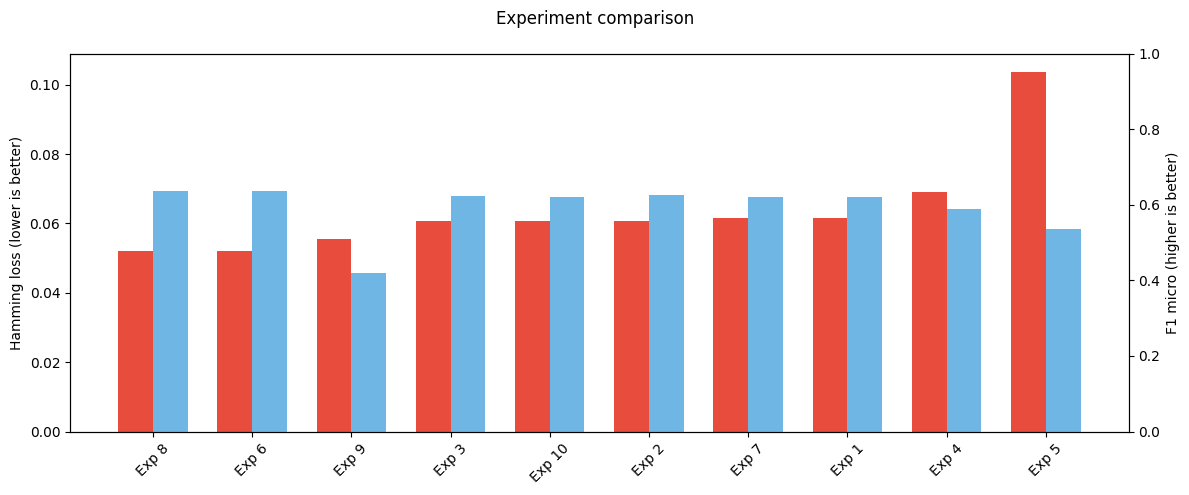

Saved: results/experiment_comparison.png


In [20]:
os.makedirs("results", exist_ok=True)

# Save experiment table for report
experiments.sort_values("hamming_loss").to_csv("results/experiments_summary.csv", index=False)
print("Saved: results/experiments_summary.csv")

# Comparison figure: Hamming loss + F1 micro
fig, ax1 = plt.subplots(figsize=(12, 5))
plot_df = experiments.sort_values("hamming_loss")
x = np.arange(len(plot_df))
labels = [f"Exp {int(i)}" for i in plot_df["experiment"]]
width = 0.35
ax1.bar(x - width/2, plot_df["hamming_loss"], width, label="Hamming loss", color="#e74c3c")
ax1.set_ylabel("Hamming loss (lower is better)")
ax1.set_xticks(x)
ax1.set_xticklabels(labels, rotation=45)
ax2 = ax1.twinx()
ax2.bar(x + width/2, plot_df["f1_micro"], width, label="F1 micro", color="#3498db", alpha=0.7)
ax2.set_ylabel("F1 micro (higher is better)")
ax2.set_ylim(0, 1)
fig.suptitle("Experiment comparison")
fig.tight_layout()
fig.savefig("results/experiment_comparison.png", dpi=150)
plt.show()
print("Saved: results/experiment_comparison.png")

Best experiment 8 — per-label metrics (validation):



,indicator,precision,recall,f1,support
4,"3.3.1 - Number of new HIV infections per 1,000...",0.956,0.833,0.890,78
5,"3.3.2 - Tuberculosis incidence per 100,000 pop...",0.872,0.723,0.791,47
6,"3.3.3 - Malaria incidence per 1,000 population",0.886,0.689,0.775,45
15,3.7.2 - Adolescent birth rate (aged 10_14 year...,0.786,0.688,0.733,32
9,3.4.1 - Mortality rate attributed to cardiovas...,0.731,0.731,0.731,93
23,3.b.2 - Total net official development assista...,0.708,0.712,0.710,215
19,3.9.2 - Mortality rate attributed to unsafe wa...,0.676,0.639,0.657,36
14,3.7.1 - Proportion of women of reproductive ag...,0.667,0.629,0.647,35
22,3.b.1 - Proportion of the target population co...,0.657,0.590,0.622,39
26,3.d.1 - International Health Regulations (IHR)...,0.600,0.643,0.621,42


                                          precision    recall  f1-score   support

        3.1.1 - Maternal mortality ratio       0.49      0.57      0.52        30
3.1.2 - Proportion of births attended by       0.13      0.11      0.12        18
          3.2.1 - Under-5 mortality rate       0.67      0.53      0.59        45
         3.2.2 - Neonatal mortality rate       0.44      0.21      0.29        19
3.3.1 - Number of new HIV infections per       0.96      0.83      0.89        78
3.3.2 - Tuberculosis incidence per 100,0       0.87      0.72      0.79        47
3.3.3 - Malaria incidence per 1,000 popu       0.89      0.69      0.78        45
3.3.4 - Hepatitis B incidence per 100,00       0.86      0.35      0.50        17
3.3.5 - Number of people requiring inter       0.59      0.59      0.59        34
3.4.1 - Mortality rate attributed to car       0.73      0.73      0.73        93
          3.4.2 - Suicide mortality rate       0.39      0.64      0.48        11
3.5.1 - Coverag

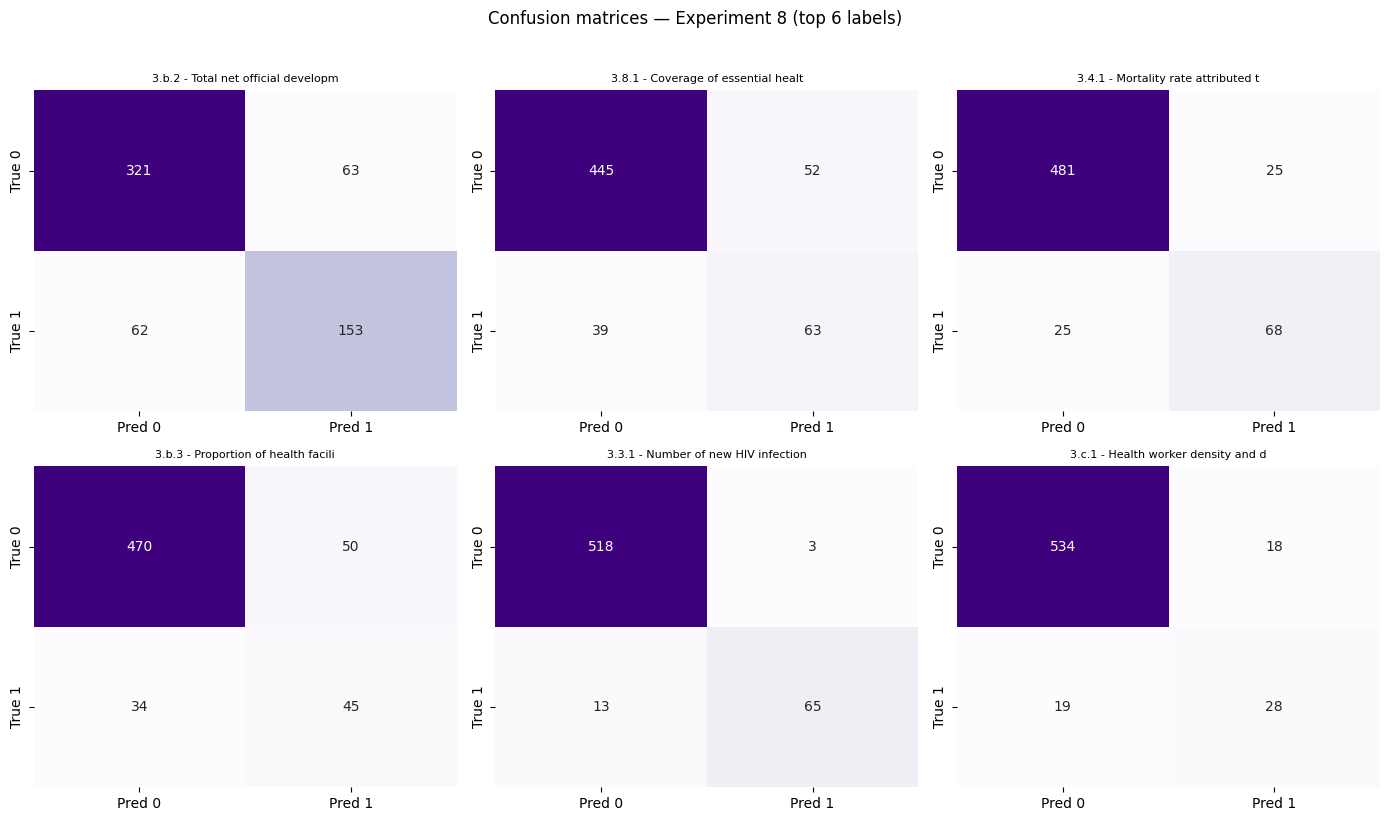

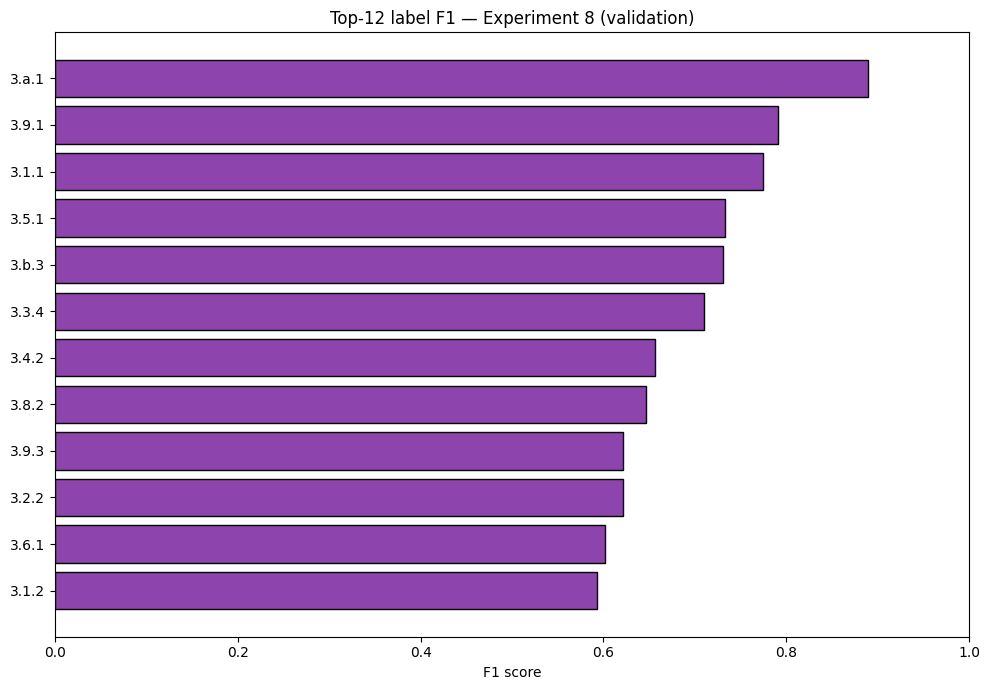

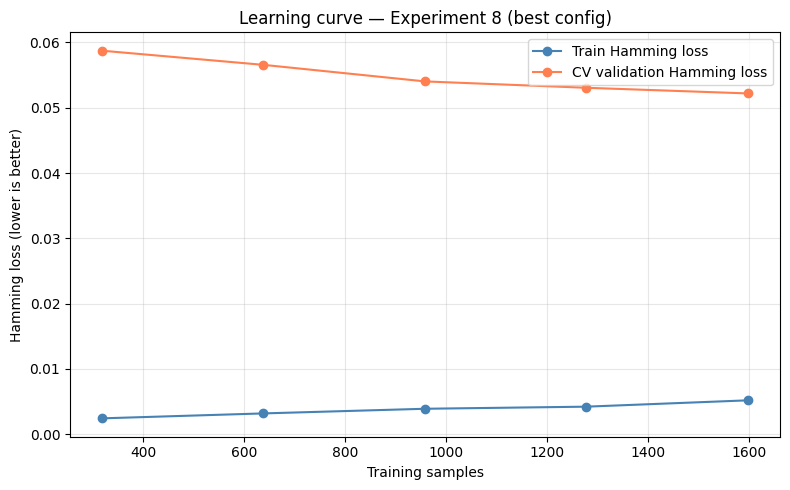

Best experiment: 8
  Hamming loss: 0.0520
Saved: results/best_model_per_label_metrics.csv, best_model_per_label_f1.png,
       best_model_confusion_matrices.png, best_model_learning_curve.png


In [21]:
# Full multi-label classification report for best experiment
best_id = int(experiments.sort_values("hamming_loss").iloc[0]["experiment"])
best_cfg = next(c for c in experiment_configs if c["id"] == best_id)

idx = np.arange(len(train_df))
idx_train, idx_val = train_test_split(idx, test_size=TEST_SIZE, random_state=RANDOM_STATE)
series = best_cfg["text"]

vec = TfidfVectorizer(**best_cfg["vec"])
X_tr = vec.fit_transform(series.iloc[idx_train])
X_va = vec.transform(series.iloc[idx_val])
y_tr, y_va = y[idx_train], y[idx_val]

clf = OneVsRestClassifier(best_cfg["estimator"])
clf.fit(X_tr, y_tr)

threshold = best_cfg["threshold"]
if threshold != 0.5 and hasattr(clf, "predict_proba"):
    y_pred = (clf.predict_proba(X_va) >= threshold).astype(int)
elif threshold != 0.5 and hasattr(clf, "decision_function"):
    y_pred = (clf.decision_function(X_va) >= threshold).astype(int)
else:
    y_pred = clf.predict(X_va)

label_metrics = multilabel_report(y_va, y_pred, label_names)
print(f"Best experiment {best_id} — per-label metrics (validation):\n")
display(label_metrics)

print(classification_report(
    y_va, y_pred,
    target_names=[n[:40] for n in label_names],
    zero_division=0,
))

# Confusion matrices for top 6 labels
top6_idx = np.argsort(y_va.sum(axis=0))[::-1][:6]
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
mcm = multilabel_confusion_matrix(y_va, y_pred)
for ax, li in zip(axes.ravel(), top6_idx):
    tn, fp, fn, tp = mcm[li].ravel()
    sns.heatmap(
        np.array([[tn, fp], [fn, tp]]),
        annot=True, fmt="d", cmap="Purples", cbar=False, ax=ax,
        xticklabels=["Pred 0", "Pred 1"], yticklabels=["True 0", "True 1"],
    )
    ax.set_title(label_names[li][:35], fontsize=8)
fig.suptitle(f"Confusion matrices — Experiment {best_id} (top 6 labels)", y=1.02)
plt.tight_layout()
fig.savefig("results/best_model_confusion_matrices.png", dpi=150)
plt.show()

short = label_metrics["indicator"].str.replace(r"^(\d+\.\S+) - .*", r"\1", regex=True)
fig, ax = plt.subplots(figsize=(10, 7))
top = label_metrics.head(12).iloc[::-1]
ax.barh(short.iloc[::-1][:12], top["f1"].values, color="#8e44ad", edgecolor="black")
ax.set_xlim(0, 1)
ax.set_xlabel("F1 score")
ax.set_title(f"Top-12 label F1 — Experiment {best_id} (validation)")
plt.tight_layout()
fig.savefig("results/best_model_per_label_f1.png", dpi=150)
plt.show()

# Learning curve for best experiment (Hamming loss vs training size)
train_sizes = np.linspace(0.2, 1.0, 5)

def hamming_scorer(estimator, X, y_true):
    return -hamming_loss(y_true, estimator.predict(X))

best_estimator = best_cfg["estimator"]
lc_clf = OneVsRestClassifier(best_estimator)
train_sz, train_scores, val_scores = learning_curve(
    lc_clf, X_tr, y_tr,
    train_sizes=train_sizes, cv=3, scoring=hamming_scorer, n_jobs=-1,
)
train_hl = -train_scores.mean(axis=1)
val_hl = -val_scores.mean(axis=1)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(train_sz, train_hl, "o-", label="Train Hamming loss", color="steelblue")
ax.plot(train_sz, val_hl, "o-", label="CV validation Hamming loss", color="coral")
ax.set_xlabel("Training samples")
ax.set_ylabel("Hamming loss (lower is better)")
ax.set_title(f"Learning curve — Experiment {best_id} (best config)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
fig.savefig("results/best_model_learning_curve.png", dpi=150)
plt.show()

label_metrics.to_csv("results/best_model_per_label_metrics.csv", index=False)
print(f"Best experiment: {best_id}")
print(f"  Hamming loss: {experiments.sort_values('hamming_loss').iloc[0]['hamming_loss']:.4f}")
print("Saved: results/best_model_per_label_metrics.csv, best_model_per_label_f1.png,")
print("       best_model_confusion_matrices.png, best_model_learning_curve.png")
